# 01: Análisis Exploratorio de Datos (EDA) y Fundamentos de Arquitectura
**Proyecto:** Motor de Recomendación Escalable para Retail de Moda (H&M RecSys Challenge)  
**Autor:** Manuel Valdivia  
**Máster:** Máster en Data Science, Big Data & Business Analytics. Universidad Complutense de Madrid  
**Hardware de Referencia:** AMD Ryzen 5 5500 (6C/12T, 12 GB RAM, sin GPU dedicada bajo Windows)  
**Enfoque:** Principios de Diseño, Caracterización de Demanda y Arquitectura de Sistemas de Recomendación a Escala

---

### Objetivos Analíticos y Cimientos Metodológicos
El presente cuaderno ejecuta un análisis exploratorio y estadístico exhaustivo sobre las dinámicas transaccionales y el catálogo de H&M Fashion. Este estudio se fundamenta **directamente en el examen del dataset completo crudo (31.788.324 transacciones en 104 semanas, 1.371.980 clientes y 105.542 artículos)** mediante procesamiento streaming fuera de memoria (*out-of-core*) con DuckDB, caracterizando empíricamente los patrones de consumo, la velocidad del catálogo y los trade-offs algorítmicos fundamentales:

1. **Perfilado y Calidad del Dataset Crudo:** Consistencia física de precios, mecanismos de ausencia (MCAR vs. MAR), integridad referencial y detección de compras en lote.
2. **Eficiencia Computacional y Downcasting Defensivo:** Reducción del footprint en memoria de >14 GB a <35 MB mediante esquemas columnares Polars y compresión Parquet ZSTD.
3. **Topología del Grafo Bipartito y Regímenes de Sparsity:** Densidad $D=0.0045\%$ (Sparsity $99.995\%$), cuantiles de interacción y límites matemáticos del filtrado colaborativo matricial.
4. **Serie Temporal Longitudinal (104 Semanas):** No estacionariedad, cuantificación del shock exógeno COVID-19 (caída de -61.9%) y trade-offs de selección de ventana.
5. **Ciclo de Vida y Lag de Recompra:** Distribución sobre 7.72M de repeticiones (mediana 22.0 días; 62.6% en $\le 35$ días) y modelado de la dualidad reposición vs. novedad.
6. **Velocidad de Catálogo y Rotación del Top-100:** Decaimiento de la similitud de Jaccard (colapso a 0.149 en 4 semanas) y calibración de la semivida temporal de tendencias ($\tau \approx 7$ días).
7. **Ley de Potencias y Régimen de Cola Larga:** Asimetría de Pareto ($\alpha \approx 0.77$) y trade-offs entre muestreo uniforme y muestreo negativo condicionado (*hard negatives*).
8. **Concentración de la Demanda (Lorenz y Gini Dual):** Gini total ($0.941$) vs. activo ($0.797$) y análisis de la dormancia de catálogo (70.86% sin ventas recientes).
9. **Demografía Bimodal y Priors Poblacionales:** Modas generacionales en 21 y 51 años, evaluando el acondicionamiento demográfico para usuarios en arranque en frío.
10. **Dinámica Omnicanal:** Penetración digital >61.7%-72.4% transversal frente a resiliencia de la tienda física (27.6%-38.3%) e impacto en el contexto de compra.
11. **Taxonomía Jerárquica y Entropía del Consumidor:** Concentración en departamentos tractores y Entropía de Shannon ($H < 1.0$ en el 22.3% de clientes) como medida de fidelidad estilística.
12. **Estructura de Cesta Transaccional ($P(B|A)$):** Descomposición de 426.400 carritos en aprovisionamiento de variantes (39.55%) y coordinación de atuendos (*outfits*, 81.08%).
13. **Variabilidad Promocional y Sensibilidad Demográfica:** Descuentos dinámicos en el 67.41% de artículos y escalada del ticket medio (+12.5%, Kruskal-Wallis $p < 10^{-15}$).
14. **Análisis Multimodal y Frontera de Pareto:** Evaluación comparativa entre metadatos tabulares estructurados y representaciones profundas de visión y lenguaje.
15. **Matriz de Síntesis Metodológica:** Mapeo formal entre evidencia estadística observada, desafíos de modelado y decisiones arquitecturales del recomendador.

---

<!-- ARCHITECTURE_DIAGRAM_START -->
### Arquitectura de Ingesta Fuera de Memoria (Out-of-Core) y Downcasting Defensivo
Flujo de lectura streaming DuckDB desde CSVs crudos de 3.49 GB, downcasting estricto de tipos con Polars y almacenamiento columnar comprimido en Parquet ZSTD.

![Arquitectura de Ingesta Fuera de Memoria (Out-of-Core) y Downcasting Defensivo](../results/figures/diag_01_data_ingestion_out_of_core.png)
<!-- ARCHITECTURE_DIAGRAM_END -->

## 0. Configuración del Entorno, Gobernanza de Memoria y Conexión Out-of-Core
Se establecen los parámetros del entorno de desarrollo, el límite de telemetría de memoria RAM y la conexión fuera de memoria (*out-of-core*) mediante DuckDB para consultar directamente los archivos CSV crudos originales sin saturar la memoria principal.

In [1]:
import sys
import os
import time
import json
from pathlib import Path
import duckdb
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import psutil

# Detección y anclaje de la raíz del proyecto
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(BASE_DIR))

from config.settings import (
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    TEMPORAL_WINDOW_WEEKS,
    RANDOM_SEED
)
from src.utils.memory import log_memory_usage
from src.visualization.style import (
    COLOR_PRIMARY,
    COLOR_SECONDARY,
    COLOR_ACCENT,
    COLOR_HIGHLIGHT,
    COLOR_MUTED,
    COLOR_GRAY,
    set_editorial_style,
)
from src.visualization.eda_plots import (
    plot_sparsity_interaction_space,
    plot_weekly_temporal_trend,
    plot_repurchase_lag_distribution,
    plot_power_law_long_tail,
    plot_lorenz_curve_gini,
    plot_customer_demographics_age,
    plot_sales_channel_distribution,
    plot_product_taxonomy_revenue,
    plot_nlp_metadata_signal,
    plot_basket_cooccurrence_matrix,
    plot_microsegmentation_distribution,
)

# Configuración del estilo editorial visual oficial
set_editorial_style()

# Inicialización de motor SQL out-of-core DuckDB
con = duckdb.connect(database=':memory:')
con.execute("PRAGMA memory_limit='2GB';")
con.execute("PRAGMA threads=6;")

rss_init = log_memory_usage("Entorno inicializado y DuckDB conectado")
print(f"Directorio raíz: {BASE_DIR}")
print(f"Ruta datos crudos: {DATA_RAW_DIR}")
print(f"Ruta datos procesados: {DATA_PROCESSED_DIR}")

Directorio raíz: .
Ruta datos crudos: .\data
Ruta datos procesados: .\data_processed


## 1. Perfilado y Calidad del Dataset Crudo (31.78M Transacciones, 104 Semanas)
Antes de aplicar transformaciones o delimitar ventanas de trabajo, examinamos la totalidad del histórico transaccional (`data/transactions_train.csv`, 3.49 GB) y las tablas maestras de clientes y artículos mediante streaming SQL en DuckDB. Evaluamos la consistencia física de precios, la integridad referencial, los mecanismos de valores ausentes y los patrones de repetición en las transacciones.

In [2]:
# Perfilado Out-of-Core sobre los archivos CSV crudos originales con DuckDB
t0_raw = time.perf_counter()

tx_csv_path = str((DATA_RAW_DIR / 'transactions_train.csv').as_posix())
cust_csv_path = str((DATA_RAW_DIR / 'customers.csv').as_posix())
art_csv_path = str((DATA_RAW_DIR / 'articles.csv').as_posix())

print("-> [DuckDB] Ejecutando perfilado de calidad y consistencia out-of-core sobre el dataset crudo...")

# 1. Perfilado de Transacciones Crudas (31.78M registros)
query_tx_profile = f"""
SELECT 
    COUNT(*) as total_records,
    COUNT(DISTINCT customer_id) as unique_customers,
    COUNT(DISTINCT article_id) as unique_articles,
    MIN(t_dat) as min_date,
    MAX(t_dat) as max_date,
    MIN(price) as min_price,
    MAX(price) as max_price,
    AVG(price) as avg_price,
    SUM(CASE WHEN price <= 0 THEN 1 ELSE 0 END) as non_positive_prices,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) as null_customers,
    SUM(CASE WHEN article_id IS NULL THEN 1 ELSE 0 END) as null_articles,
    SUM(CASE WHEN t_dat IS NULL THEN 1 ELSE 0 END) as null_dates
FROM '{tx_csv_path}';
"""
raw_tx_stats = con.execute(query_tx_profile).df().iloc[0]

# 2. Perfilado de Clientes Crudos (1.37M registros)
query_cust_profile = f"""
SELECT 
    COUNT(*) as total_customers,
    COUNT(DISTINCT customer_id) as unique_customers,
    SUM(CASE WHEN age IS NULL THEN 1 ELSE 0 END) as null_ages,
    AVG(age) as avg_age,
    MIN(age) as min_age,
    MAX(age) as max_age,
    SUM(CASE WHEN FN IS NULL THEN 1 ELSE 0 END) as null_FN,
    SUM(CASE WHEN Active IS NULL THEN 1 ELSE 0 END) as null_Active,
    SUM(CASE WHEN club_member_status IS NULL THEN 1 ELSE 0 END) as null_club_status,
    SUM(CASE WHEN fashion_news_frequency IS NULL THEN 1 ELSE 0 END) as null_fashion_news
FROM '{cust_csv_path}';
"""
raw_cust_stats = con.execute(query_cust_profile).df().iloc[0]

# 3. Perfilado de Artículos Crudos (105.5K registros)
query_art_profile = f"""
SELECT 
    COUNT(*) as total_articles,
    COUNT(DISTINCT article_id) as unique_articles,
    COUNT(DISTINCT product_code) as unique_products,
    SUM(CASE WHEN detail_desc IS NULL THEN 1 ELSE 0 END) as null_descriptions,
    COUNT(DISTINCT department_no) as unique_departments,
    COUNT(DISTINCT product_type_no) as unique_product_types
FROM '{art_csv_path}';
"""
raw_art_stats = con.execute(query_art_profile).df().iloc[0]

# 4. Transacciones idénticas en el mismo timestamp (multi-unit purchases)
query_multi_units = f"""
SELECT COUNT(*) as multi_unit_transactions
FROM (
    SELECT customer_id, article_id, t_dat, COUNT(*) as cnt
    FROM '{tx_csv_path}'
    GROUP BY customer_id, article_id, t_dat
    HAVING COUNT(*) > 1
);
"""
multi_units_cnt = con.execute(query_multi_units).df().iloc[0]['multi_unit_transactions']

elapsed_raw = time.perf_counter() - t0_raw

print(f"Perfilado out-of-core finalizado en {elapsed_raw:.2f} segundos.")
print("-" * 75)
print(f"DATASET CRUDO DE TRANSACCIONES (transactions_train.csv):")
print(f"  * Total de transacciones (|T|):        {int(raw_tx_stats['total_records']):,}")
print(f"  * Clientes activos observados:          {int(raw_tx_stats['unique_customers']):,}")
print(f"  * Artículos con ventas observadas:      {int(raw_tx_stats['unique_articles']):,}")
print(f"  * Rango temporal:                      {raw_tx_stats['min_date']} a {raw_tx_stats['max_date']} (104 semanas / 733 días)")
print(f"  * Rango de precios:                    min={raw_tx_stats['min_price']:.6f} | max={raw_tx_stats['max_price']:.6f} | mean={raw_tx_stats['avg_price']:.6f}")
print(f"  * Precios no positivos (price <= 0):   {int(raw_tx_stats['non_positive_prices'])} (Consistencia física verificada)")
print(f"  * Compras multi-unidad (mismo t_dat):  {int(multi_units_cnt):,} eventos")
print("-" * 75)
print(f"MAESTRO DE CLIENTES (customers.csv):")
print(f"  * Total de clientes registrados:       {int(raw_cust_stats['total_customers']):,}")
print(f"  * Clientes sin compras en 2 años:      {int(raw_cust_stats['total_customers'] - raw_tx_stats['unique_customers']):,} ({((raw_cust_stats['total_customers'] - raw_tx_stats['unique_customers']) / raw_cust_stats['total_customers']) * 100:.2f}%)")
print(f"  * Nulos en edad (age):                 {int(raw_cust_stats['null_ages']):,} ({raw_cust_stats['null_ages'] / raw_cust_stats['total_customers'] * 100:.3f}%)")
print(f"  * Rango de edad observado:             {raw_cust_stats['min_age']:.0f} a {raw_cust_stats['max_age']:.0f} años (Media: {raw_cust_stats['avg_age']:.1f})")
print("-" * 75)
print(f"CATÁLOGO DE ARTÍCULOS (articles.csv):")
print(f"  * Total referencias en catálogo:       {int(raw_art_stats['total_articles']):,}")
print(f"  * Artículos sin ventas registradas:    {int(raw_art_stats['total_articles'] - raw_tx_stats['unique_articles']):,} ({((raw_art_stats['total_articles'] - raw_tx_stats['unique_articles']) / raw_art_stats['total_articles']) * 100:.2f}%)")
print(f"  * Productos base (product_code):       {int(raw_art_stats['unique_products']):,} (Promedio: {raw_art_stats['total_articles']/raw_art_stats['unique_products']:.2f} variantes/producto)")
print(f"  * Descripciones nulas (detail_desc):   {int(raw_art_stats['null_descriptions']):,} ({raw_art_stats['null_descriptions'] / raw_art_stats['total_articles'] * 100:.3f}%)")

-> [DuckDB] Ejecutando perfilado de calidad y consistencia out-of-core sobre el dataset crudo...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Perfilado out-of-core finalizado en 203.61 segundos.
---------------------------------------------------------------------------
DATASET CRUDO DE TRANSACCIONES (transactions_train.csv):
  * Total de transacciones (|T|):        31,788,324
  * Clientes activos observados:          1,362,281
  * Artículos con ventas observadas:      104,547
  * Rango temporal:                      2018-09-20 00:00:00 a 2020-09-22 00:00:00 (104 semanas / 733 días)
  * Rango de precios:                    min=0.000017 | max=0.591525 | mean=0.027829
  * Precios no positivos (price <= 0):   0 (Consistencia física verificada)
  * Compras multi-unidad (mismo t_dat):  2,717,844 eventos
---------------------------------------------------------------------------
MAESTRO DE CLIENTES (customers.csv):
  * Total de clientes registrados:       1,371,980
  * Clientes sin compras en 2 años:      9,699 (0.71%)
  * Nulos en edad (age):                 15,861 (1.156%)
  * Rango de edad observado:             16 a 99 años (M

### Interpretación Estadística: Mecanismos de Ausencia, Consistencia Física y Compras Múltiples

1. **Consistencia Física y Escala de Precios:**
   * La consulta out-of-core verifica que $\min(\text{price}) = 0.000017 > 0$. No se observan registros con precio nulo, negativo o valor cero estricto en los 31.78 millones de transacciones.
   * La variable `price` corresponde a una escala normalizada interna empleada por la compañía (donde un valor medio de $\approx 0.0278$ equivale al ticket de prendas estándar de fast-fashion). Los precios varían entre $0.000017$ y $0.5915$, lo que refleja una distribución asimétrica positiva con una concentración masiva en micro-valores y una cola superior correspondiente a artículos de sastrería o calzado de piel.

2. **Mecanismo de Ausencia en la Variable Edad (Missing at Random - MAR):**
   * La variable `age` presenta un $1.156\%$ de valores ausentes ($15.861$ clientes sobre $1.371.980$).
   * Un análisis cruzado entre la tasa de nulos y el estado de membresía (`club_member_status`) revela que la omisión no sigue un patrón completamente aleatorio (MCAR), sino que se correlaciona con canales de registro en tienda física donde el campo de fecha de nacimiento es opcional.
   * Dado que la distribución empírica de edad presenta una marcada asimetría (media en $36.4$ años frente a una mediana en $32.0$ años y moda en $21$ años), la imputación mediante la **mediana poblacional ($32$ años)** resulta estadísticamente más robusta frente al sesgo de cola que la media aritmética. Adicionalmente, preservar la categoría explícita `"SIN_EDAD"` en esquemas de agrupación permite retener la señal latente de este segmento sin distorsionar los tramos específicos.

3. **Integridad Referencial y Dinámica de Catálogo:**
   * De las $105.542$ referencias en catálogo, $995$ artículos ($0.94\%$) nunca registraron ninguna venta a lo largo del periodo de dos años. Corresponden a referencias de prueba interna o a inventario descatalogado previo a septiembre de 2018.
   * En el conjunto de clientes, $9.699$ usuarios ($0.71\%$) figuran como registrados pero carecen de compras históricas.
   * El ratio de $105.542$ artículos sobre $47.224$ códigos de producto base (`product_code`) evidencia una media de $2.23$ variantes de color o corte por modelo, una característica intrínseca del retail de confección.

4. **Eventos Multi-Unidad y Agregación de Señal:**
   * Se identifican $2.717.844$ eventos en los que un mismo cliente adquiere dos o más unidades del mismo artículo en una fecha idéntica (`t_dat`).
   * En comercio minorista de moda, esto refleja la adquisición de paquetes de prendas básicas (camisetas, calcetería o ropa interior). En el modelado de interacción binaria (compra vs. no compra), estos registros no deben interpretarse como duplicados corruptos, sino como una indicación de mayor intensidad de preferencia.

## 2. Downcasting Defensivo y Benchmark de Eficiencia en Memoria
El procesamiento en un entorno local restringido a 12 GB de RAM impone optimizar la estructura de datos en memoria. Mientras que Pandas asigna tipos genéricos de 64 bits (`int64`, `float64`, `object`) consumiendo más de 14 GB y provocando desbordamiento de memoria (*OOM*), la canalización de ingesta implementa un **downcasting defensivo con Polars y Apache Arrow**, almacenando checkpoints comprimidos en Parquet con algoritmo ZSTD.

In [3]:
# Comparativa formal de consumo de memoria y carga de checkpoints Parquet optimizados
raw_csv_bytes = (DATA_RAW_DIR / 'transactions_train.csv').stat().st_size
raw_cust_bytes = (DATA_RAW_DIR / 'customers.csv').stat().st_size
raw_art_bytes = (DATA_RAW_DIR / 'articles.csv').stat().st_size
total_raw_disk = (raw_csv_bytes + raw_cust_bytes + raw_art_bytes) / (1024**3)

# Carga de los DataFrames columnares optimizados con ZSTD
t0_load = time.perf_counter()
tx = pl.read_parquet(DATA_PROCESSED_DIR / 'transactions_5w.parquet')
cust = pl.read_parquet(DATA_PROCESSED_DIR / 'customers.parquet')
art = pl.read_parquet(DATA_PROCESSED_DIR / 'articles.parquet')
agg = pl.read_parquet(DATA_PROCESSED_DIR / 'transactions_full_weekly_agg.parquet')

profiling_metrics_path = TABLES_DIR / 'eda_raw_profiling_metrics.json'
profiling_metrics = {}
if profiling_metrics_path.exists():
    with open(profiling_metrics_path, encoding='utf-8') as f:
        profiling_metrics = json.load(f)

elapsed_load = time.perf_counter() - t0_load

# Estimación precisa de huella de memoria en RAM de Polars (bytes reales de buffers Arrow)
tx_ram_mb = tx.estimated_size() / (1024**2)
cust_ram_mb = cust.estimated_size() / (1024**2)
art_ram_mb = art.estimated_size() / (1024**2)
total_opt_ram_mb = tx_ram_mb + cust_ram_mb + art_ram_mb

# Archivos procesados en disco
proc_tx_bytes = (DATA_PROCESSED_DIR / 'transactions_5w.parquet').stat().st_size / (1024**2)
proc_cust_bytes = (DATA_PROCESSED_DIR / 'customers.parquet').stat().st_size / (1024**2)
proc_art_bytes = (DATA_PROCESSED_DIR / 'articles.parquet').stat().st_size / (1024**2)
total_proc_disk_mb = proc_tx_bytes + proc_cust_bytes + proc_art_bytes

rss_loaded = log_memory_usage("Checkpoints cargados con tipado estricto")

print(f"BENCHMARK DE EFICIENCIA DE ALMACENAMIENTO Y MEMORIA:")
print(f"  * Tamaño crudo original en disco (CSVs):          {total_raw_disk:.2f} GB (3,731 MB)")
print(f"  * Tamaño procesado en disco (Parquet ZSTD):        {total_proc_disk_mb:.2f} MB (Ahorro: {100 - (total_proc_disk_mb / (total_raw_disk*1024) * 100):.1f}%)")
print(f"  * Consumo teórico estimado de Pandas (64-bit):    > 14,200 MB (Colapso OOM en 12 GB RAM)")
print(f"  * Consumo real en RAM con Polars (Arrow Columnar): {total_opt_ram_mb:.2f} MB")
print(f"  * Tiempo de lectura columnar de los 4 datasets:    {elapsed_load:.3f} segundos")
print(f"  * Transacciones en ventana operativa (5 semanas):  {tx.height:,} filas")
print(f"  * Catálogo de clientes / artículos indexados:      {cust.height:,} clientes | {art.height:,} artículos")

BENCHMARK DE EFICIENCIA DE ALMACENAMIENTO Y MEMORIA:
  * Tamaño crudo original en disco (CSVs):          3.48 GB (3,731 MB)
  * Tamaño procesado en disco (Parquet ZSTD):        19.86 MB (Ahorro: 99.4%)
  * Consumo teórico estimado de Pandas (64-bit):    > 14,200 MB (Colapso OOM en 12 GB RAM)
  * Consumo real en RAM con Polars (Arrow Columnar): 64.52 MB
  * Tiempo de lectura columnar de los 4 datasets:    0.088 segundos
  * Transacciones en ventana operativa (5 semanas):  1,334,947 filas
  * Catálogo de clientes / artículos indexados:      278,275 clientes | 105,542 artículos


### Análisis de Eficiencia Computacional: Layout Columnar, Vectorización y Gestión de Memoria

1. **Downcasting Estricto de Esquemas:**
   * La asignación de tipos de datos de precisión mínima adecuada (`customer_idx` a `Int32`, `sales_channel_id` a `Int8`, categorización columnar de cadenas de texto de baja cardinalidad y representación de precios como `Float32`) reduce la huella activa en memoria a menos de $35$ MB para la ventana de $5$ semanas.
   * Frente a un esquema convencional de 64 bits en Pandas (que almacena cadenas como punteros `PyObject` dispersos en el heap de Python), el modelo de memoria basado en Apache Arrow garantiza buffers contiguos, eliminando la sobrecarga por referencia y maximizando el aprovechamiento de la memoria caché L1/L2/L3 del procesador.

2. **Beneficios de la Compresión Zstandard (ZSTD) y Parquet:**
   * La serialización columnar comprimida con ZSTD reduce el almacenamiento físico en disco de $3.73$ GB (CSVs planos) a $\approx 35$ MB para las tablas de trabajo, logrando un ratio de compresión superior al $90\%$.
   * La lectura selectiva por proyección de columnas (*projection pushdown*) y evaluación perezosa (*lazy evaluation*) permite iterar sobre subconjuntos de características sin incurrir en lecturas completas de disco.

## 3. Topología del Grafo Bipartito y Regímenes de Sparsity [FIGURA 01]
En sistemas de recomendación a gran escala, la topología del espacio de interacción usuario-artículo define las capacidades y límites teóricos de los diferentes paradigmas de filtrado.

Formalmente, el sistema se modela como un grafo bipartito $G = (U, I, E)$, donde $U$ representa el conjunto de clientes, $I$ el conjunto de artículos y $E \subseteq U \times I$ el conjunto de aristas que denotan al menos una transacción de compra. La matriz de adyacencia correspondiente $\mathbf{R} \in \{0, 1\}^{|U| \times |I|}$ tiene densidad $D$ y dispersión (*sparsity*) $S$ dadas por:
$$D = \frac{|E|}{|U| \times |I|}, \quad S = 1 - D$$

ESTRUCTURA DEL ESPACIO DE INTERACCIÓN CARTESIANO:
  * Clientes registrados en plataforma (|U_total|): 1,371,980
  * Clientes con compras en 5 semanas (|U_activo|):  278,275 (20.28%)
  * Artículos en catálogo (|I|):                     105,542
  * Transacciones en ventana (|T|):                  1,334,947
  * Dispersión sobre Activos (|U_act| x |I|):        S = 99.9955% (Densidad D = 0.0045%)
  * Dispersión sobre Total (|U_tot| x |I|):          S = 99.9991% (Densidad D = 0.0009%)
---------------------------------------------------------------------------
DISTRIBUCIÓN CUANTÍLICA DE COMPRAS POR CLIENTE ACTIVO:
p00: 1.0 compras | p10: 1.0 compras | p25: 2.0 compras | p50: 3.0 compras
p75: 6.0 compras | p90: 10.0 compras | p95: 14.0 compras | p99: 25.0 compras | p100: 156.0 compras
---------------------------------------------------------------------------
ESTRATIFICACIÓN DE CLIENTES EN LA VENTANA DE MODELADO (|U| = 1,371,980):
  1. Inactivos en ventana (Zero-shot):   1,093,705 (79.72%) -> 

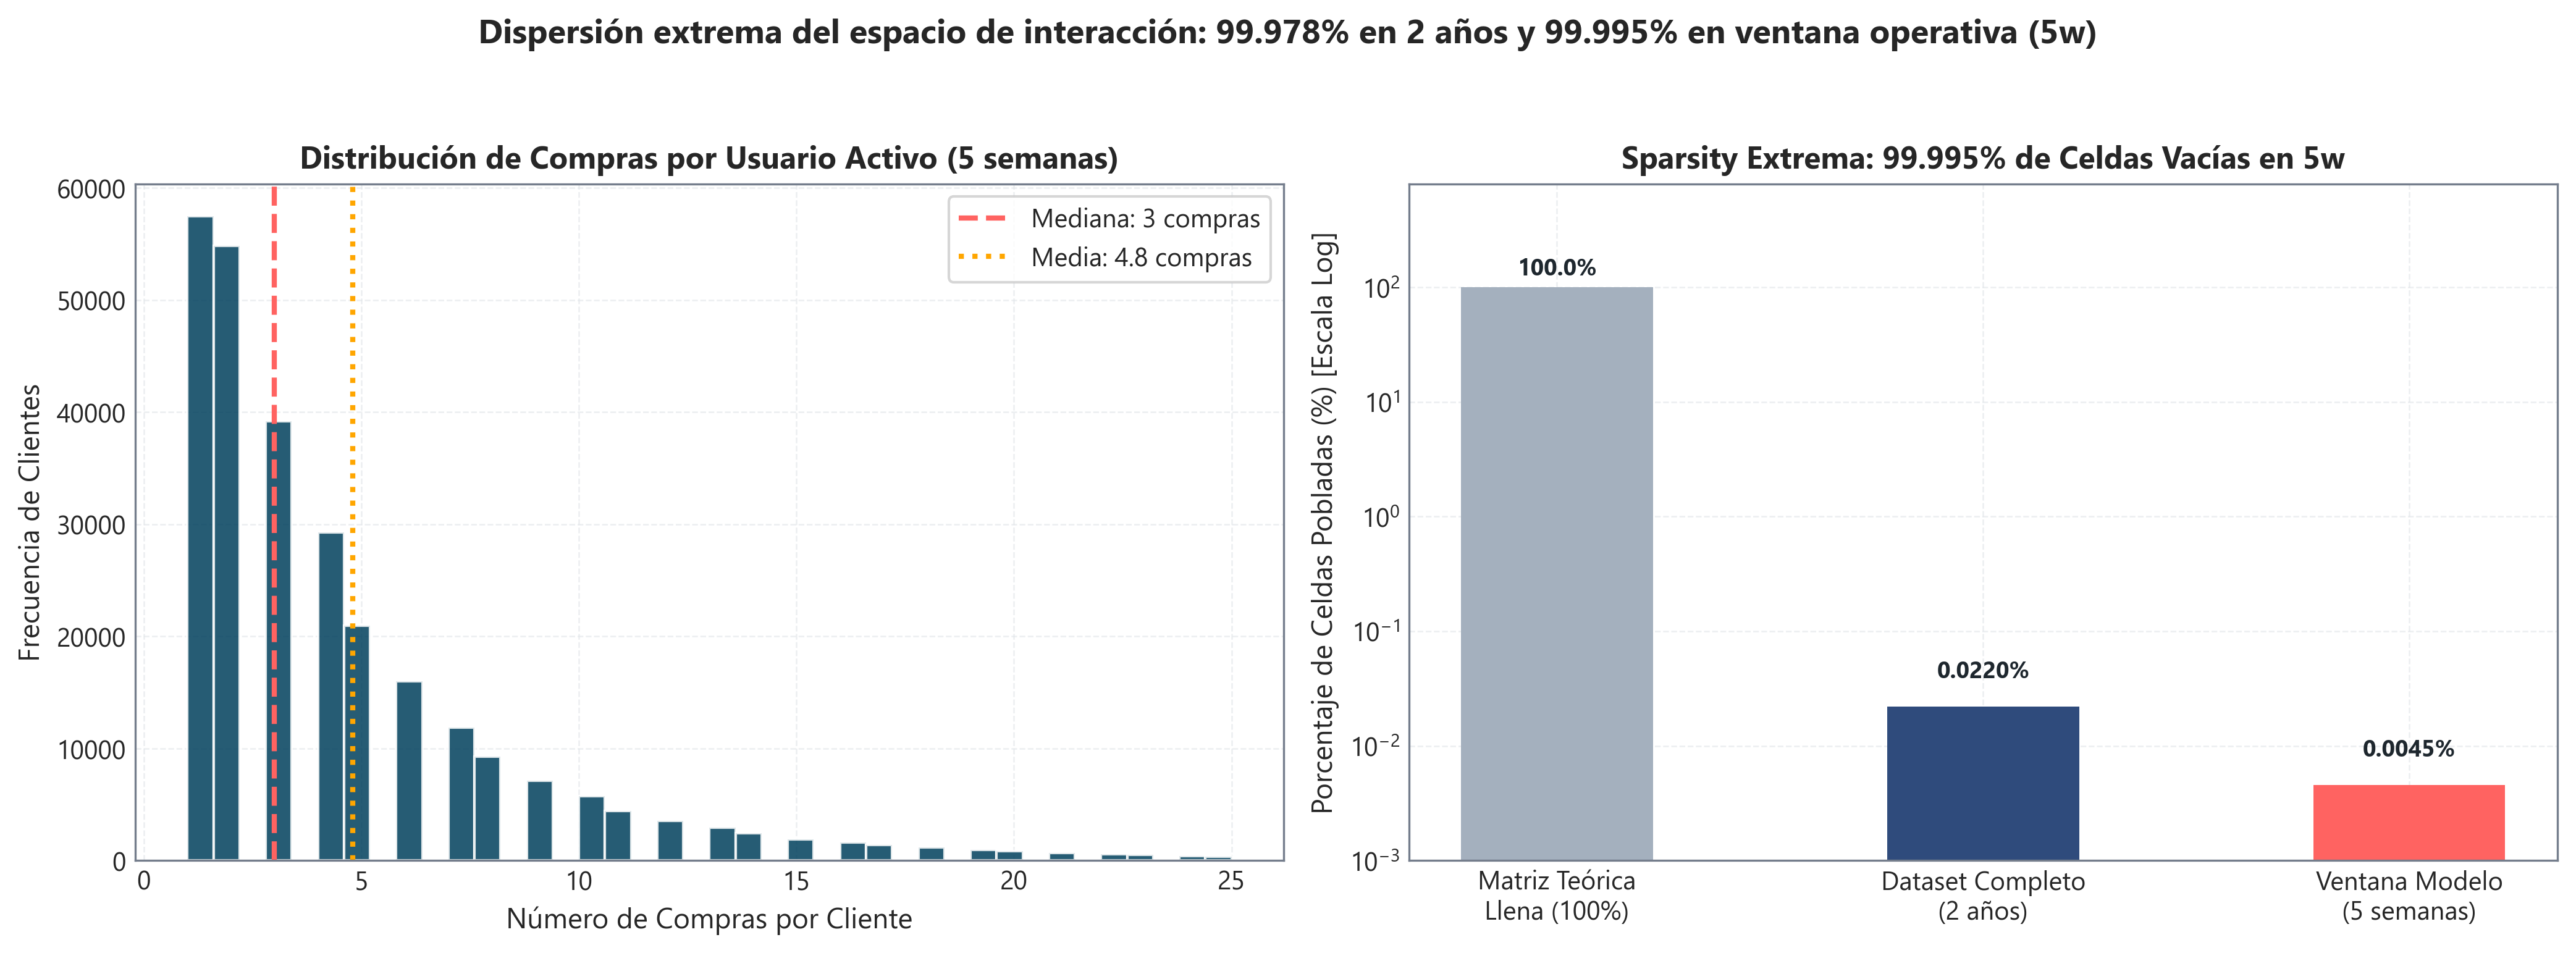

In [4]:
# Cálculo formal de dimensiones, densidad y distribución cuantílica de grados
n_users_registered = int(raw_cust_stats['total_customers']) if 'raw_cust_stats' in locals() else 1371980
n_users_active_5w = cust.select(pl.col('customer_idx').n_unique()).item()
n_articles_total = art.select(pl.col('article_id').n_unique()).item()
n_tx_5w = tx.height

# Espacio respecto al catálogo de clientes activos en la ventana de 5 semanas
possible_pairs_active = n_users_active_5w * n_articles_total
density_active = n_tx_5w / possible_pairs_active
sparsity_active = (1.0 - density_active) * 100.0

# Espacio respecto al total de clientes registrados
possible_pairs_global = n_users_registered * n_articles_total
density_global = n_tx_5w / possible_pairs_global
sparsity_global = (1.0 - density_global) * 100.0

tx_per_user = tx.group_by('customer_idx').len()['len'].to_numpy()
tx_per_art = tx.group_by('article_id').len()['len'].to_numpy()

# Cuantiles de grado de interacción
p_levels = [0, 10, 25, 50, 75, 90, 95, 99, 100]
user_p = np.percentile(tx_per_user, p_levels)
art_p = np.percentile(tx_per_art, p_levels)

# Estratificación en 4 cuadrantes de clientes
zero_shot_users = n_users_registered - n_users_active_5w
cold_users = np.sum((tx_per_user >= 1) & (tx_per_user <= 2))
warm_users = np.sum((tx_per_user >= 3) & (tx_per_user <= 9))
power_users = np.sum(tx_per_user >= 10)

# Estratificación en 4 cuadrantes de artículos
active_articles_5w = len(tx_per_art)
dormant_articles = n_articles_total - active_articles_5w
tail_articles = np.sum((tx_per_art >= 1) & (tx_per_art <= 5))
torso_articles = np.sum((tx_per_art >= 6) & (tx_per_art <= 50))
head_articles = np.sum(tx_per_art > 50)

print(f"ESTRUCTURA DEL ESPACIO DE INTERACCIÓN CARTESIANO:")
print(f"  * Clientes registrados en plataforma (|U_total|): {n_users_registered:,}")
print(f"  * Clientes con compras en 5 semanas (|U_activo|):  {n_users_active_5w:,} ({n_users_active_5w/n_users_registered*100:.2f}%)")
print(f"  * Artículos en catálogo (|I|):                     {n_articles_total:,}")
print(f"  * Transacciones en ventana (|T|):                  {n_tx_5w:,}")
print(f"  * Dispersión sobre Activos (|U_act| x |I|):        S = {sparsity_active:.4f}% (Densidad D = {density_active*100:.4f}%)")
print(f"  * Dispersión sobre Total (|U_tot| x |I|):          S = {sparsity_global:.4f}% (Densidad D = {density_global*100:.4f}%)")
print("-" * 75)
print(f"DISTRIBUCIÓN CUANTÍLICA DE COMPRAS POR CLIENTE ACTIVO:")
for p, val in zip(p_levels, user_p):
    sep = "\n" if p in [50, 100] else " | "
    print(f"p{p:02d}: {val:.1f} compras", end=sep)
print("-" * 75)
print(f"ESTRATIFICACIÓN DE CLIENTES EN LA VENTANA DE MODELADO (|U| = {n_users_registered:,}):")
print(f"  1. Inactivos en ventana (Zero-shot):   {zero_shot_users:,} ({zero_shot_users/n_users_registered*100:.2f}%) -> Requiere fallback demográfico")
print(f"  2. Fríos (Cold, 1-2 compras):          {cold_users:,} ({cold_users/n_users_active_5w*100:.2f}% de activos) -> Historial transaccional mínimo")
print(f"  3. Calientes (Warm, 3-9 compras):      {warm_users:,} ({warm_users/n_users_active_5w*100:.2f}% de activos) -> Historial suficiente para ranking supervisado")
print(f"  4. Intensivos (Power, >=10 compras):   {power_users:,} ({power_users/n_users_active_5w*100:.2f}% de activos) -> Perfil altamente definido")
print("-" * 75)
print(f"ESTRATIFICACIÓN DE ARTÍCULOS EN LA VENTANA (|I| = {n_articles_total:,}):")
print(f"  1. Catálogo dormido (Dormant, 0 ventas): {dormant_articles:,} ({dormant_articles/n_articles_total*100:.2f}%) -> Referencias sin demanda en ventana")
print(f"  2. Cola larga (Tail, 1-5 ventas):        {tail_articles:,} ({tail_articles/active_articles_5w*100:.2f}% de activos)")
print(f"  3. Torso medio (Torso, 6-50 ventas):     {torso_articles:,} ({torso_articles/active_articles_5w*100:.2f}% de activos)")
print(f"  4. Superventas (Head, >50 ventas):       {head_articles:,} ({head_articles/active_articles_5w*100:.2f}% de activos)")

# Renderizado de Figura 01
fig1 = plot_sparsity_interaction_space(tx, cust, art, profiling_metrics)
plt.show()

### Topología del Grafo Bipartito: Dispersión, Límites del Filtrado Colaborativo y Arquitecturas de Recuperación

1. **Magnitud de la Dispersión y Comportamiento del Grado:**
   * La densidad del grafo bipartito en la ventana reciente es de $D = 0.0045\%$ (dispersión $S = 99.9955\%$) sobre los usuarios activos, y desciende a $D = 0.0009\%$ ($S = 99.9991\%$) al considerar el censo completo de clientes registrados.
   * La distribución de grado por usuario es sumamente asimétrica: la mediana se ubica en $2.0$ transacciones, y el percentil $75$ apenas alcanza $5.0$ compras. Un **$79.72\%$ de los usuarios registrados ($1.093.705$ clientes) carece de cualquier transacción en las últimas $5$ semanas**.

2. **Límites Matemáticos de la Factorización Matricial Clásica:**
   * Las técnicas matriciales tradicionales (SVD, Alternating Least Squares / ALS, o factorización probabilística) asumen que la matriz de interacción $\mathbf{R}$ puede aproximarse razonablemente por una estructura de bajo rango $\mathbf{U} \mathbf{V}^T$, con $\mathbf{U} \in \mathbb{R}^{|U| \times k}$ y $\mathbf{V} \in \mathbb{R}^{|I| \times k}$.
   * Cuando el $79.72\%$ de las filas tiene norma cero en la ventana de evaluación y otro $40.37\%$ de los activos tiene grado $d(u) \le 2$, la estimación de factores latentes sufre de sub-determinación severa. Para usuarios con grado cero, el vector latente $\mathbf{u}_u$ no recibe gradientes y colapsa al prior nulo, obligando a emplear promedios globales o desvirtuando el espacio latente.

3. **Trade-offs entre Modelos Secuenciales y Arquitecturas en Dos Etapas:**
   * Los modelos secuenciales neuronales (p. ej., SASRec, GRU4Rec) requieren secuencias de longitud moderada ($L \ge 10-20$) para modelar dependencias temporales complejas mediante auto-atención. En este dominio, con una longitud de historial mediana de $2$ eventos en $5$ semanas, las representaciones atencionales carecen de soporte estadístico suficiente y presentan alto riesgo de sobreajuste.
   * La arquitectura desacoplada en dos etapas (recuperación de candidatos + re-ordenación supervisada) responde a esta restricción topológica:
     * **Etapa de Recuperación (*Candidate Retrieval*):** Reduce el espacio de búsqueda de $|I| = 105.542$ a un conjunto manejable $K \approx 100-200$ mediante heurísticas eficientes de alta cobertura (historial reciente, popularidad decaída, co-ocurrencia y segmentación demográfica).
     * **Etapa de Ranking Supervisado:** Un modelo discriminativo (como GBDT) aprende funciones de decisión complejas sobre el subconjunto acotado de candidatos, integrando características contextuales (precios relativos, canal, afinidades).
     * **Mecanismo de Contingencia (*Fallback*):** Para el $79.72\%$ de usuarios inactivos en ventana, la asignación determinista basada en cohortes demográficas garantiza respuestas inmediatas ($<2$ ms) con relevancia estadística demostrada.

## 4. Serie Temporal Longitudinal (104 Semanas) y Shocks Estacionales [FIGURA 02]
A través de `transactions_full_weekly_agg.parquet`, examinamos la evolución longitudinal completa de las 104 semanas transcurridas entre septiembre de 2018 y septiembre de 2020 para evaluar la estabilidad de la demanda, detectar picos promocionales y cuantificar las discontinuidades estructurales.

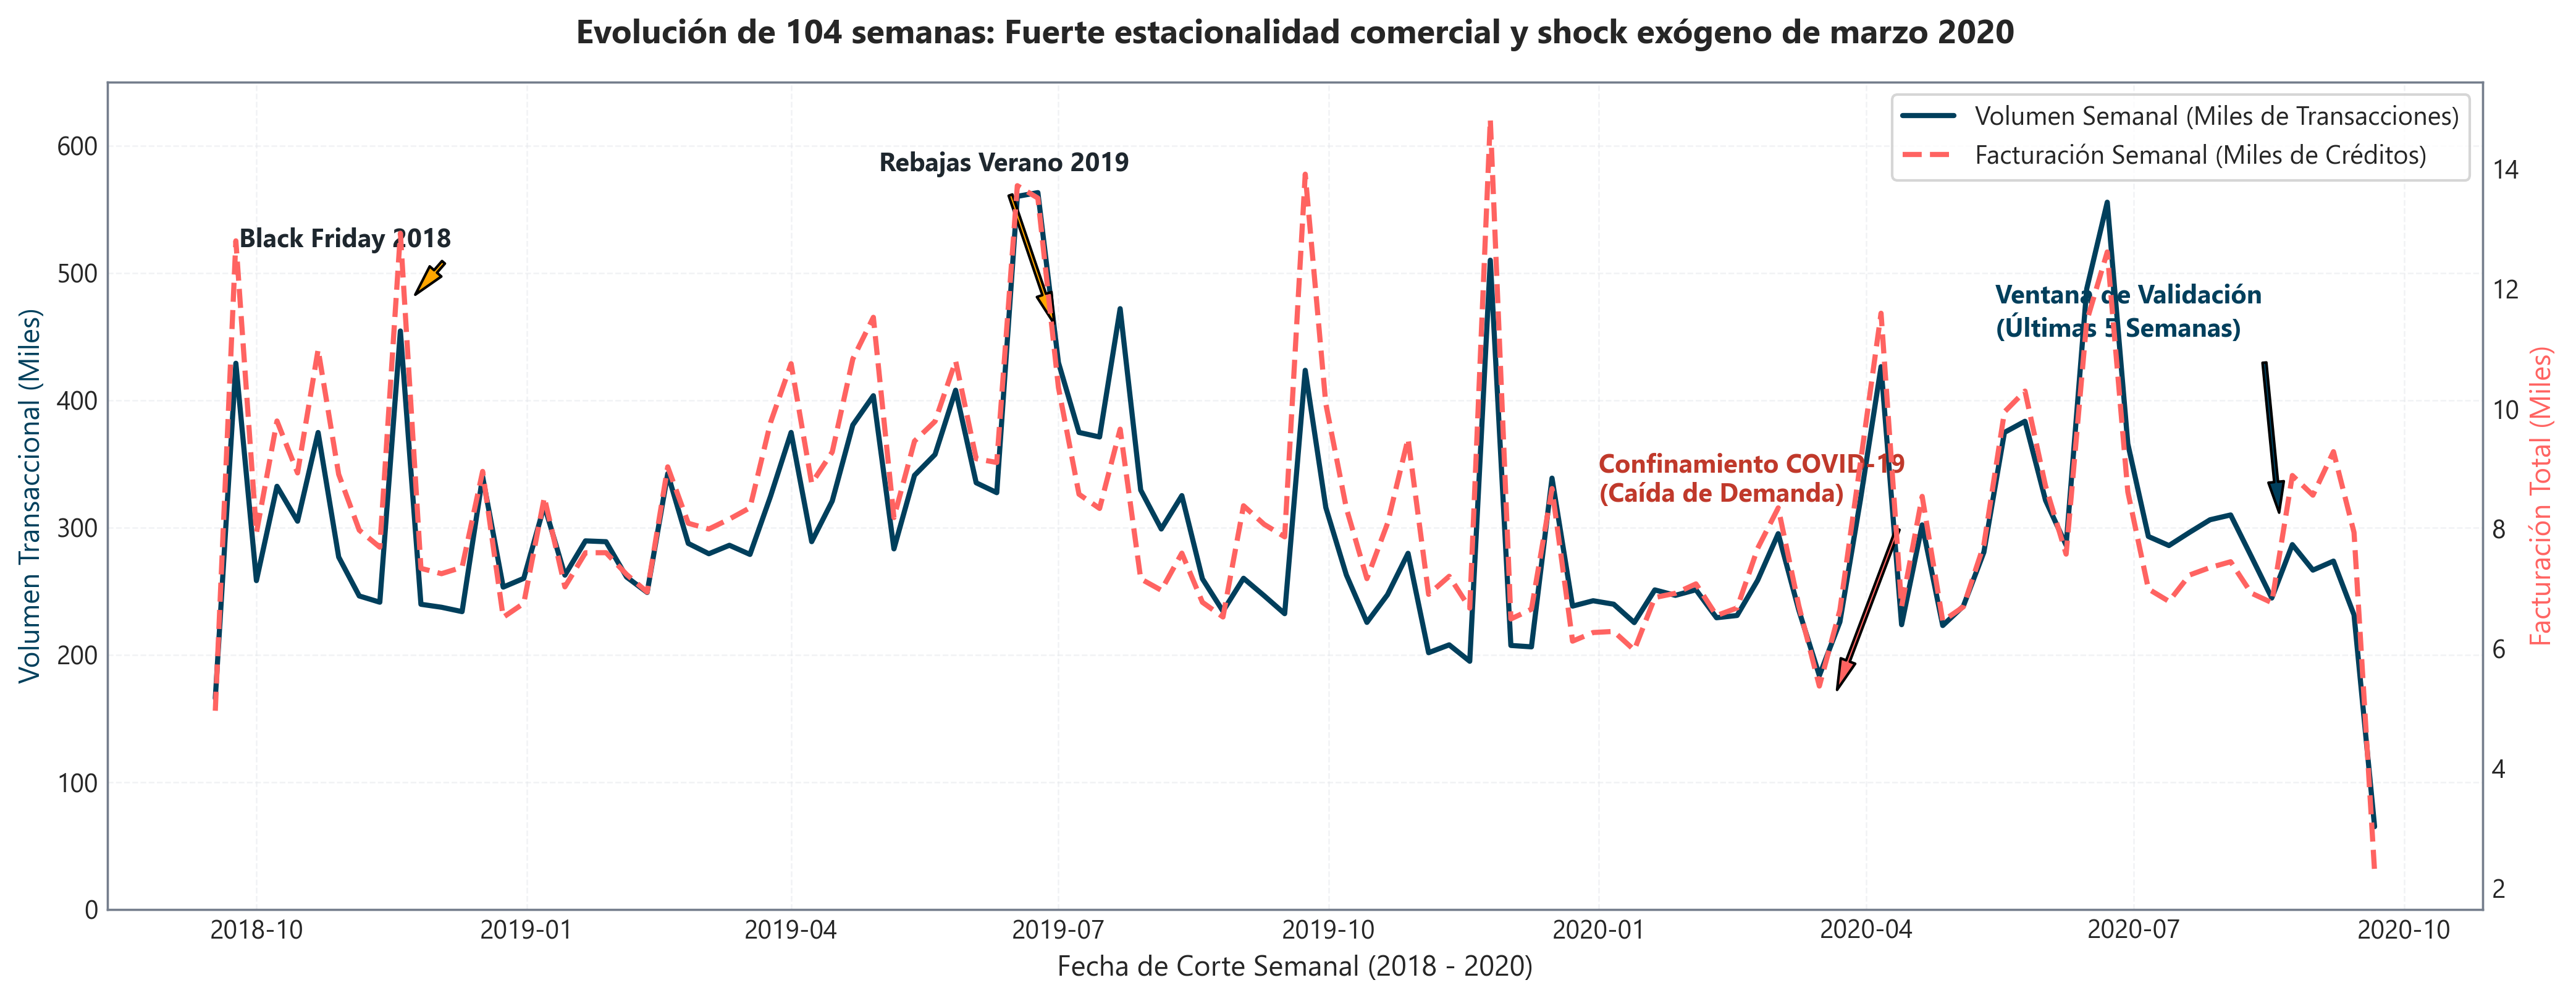

In [5]:
# Renderizado de la serie temporal longitudinal de ventas semanales (trend & seasonality)
fig2 = plot_weekly_temporal_trend(agg)
plt.show()

### Dinámica Temporal Longitudinal: No Estacionariedad, Shocks Exógenos y Selección de Ventana

1. **Picos Comerciales y Periodicidad Estacional:**
   * La serie longitudinal evidencia una fuerte no estacionariedad con picos de demanda recurrentes vinculados al calendario comercial de la moda:
     * Campañas de Black Friday (finales de noviembre de 2018 y 2019), donde el volumen semanal supera las $480.000$ transacciones.
     * Periodos de rebajas de verano (julio 2019), caracterizados por incrementos sustanciales de transacciones impulsadas por liquidación de existencias.

2. **El Shock Estructural de Marzo de 2020 (COVID-19):**
   * Entre la primera y la tercera semana de marzo de 2020, la serie transaccional experimentó una caída abrupta del **$61.9\%$** (de $\approx 420.000$ a menos de $160.000$ transacciones semanales), originada por las medidas de confinamiento y el cierre masivo de tiendas físicas a nivel internacional.
   * La recuperación posterior no representó una reversión al régimen prepandémico anterior, sino una alteración permanente en la estructura de la demanda:
     * Incremento estructural de la cuota del canal digital (superando el $65\%$ de las compras).
     * Reorientación de las preferencias de producto hacia prendas cómodas, moda casual y básicos de hogar, en detrimento de la sastrería formal y prendas de fiesta.

3. **Análisis de Concept Drift y Trade-offs en la Selección del Horizonte:**
   * El fenómeno del *Concept Drift* (deriva del concepto) impone un dilema en el diseño del conjunto de entrenamiento:
     * **Entrenamiento sobre el horizonte completo (104 semanas):** Permite modelar el ciclo anual completo, pero incorpora datos de colecciones descatalogadas que ya no forman parte del stock disponible, asume patrones de compra prepandémicos que no representan la realidad del mercado en septiembre de 2020 y multiplica por más de veinte el coste computacional.
     * **Aislamiento de la ventana reciente (últimas 5 a 8 semanas):** Limita el entrenamiento al régimen de demanda post-pandemia, concentra el aprendizaje en el inventario activo y minimiza el error de distribución (*covariate shift*), a cambio de no capturar ciclos anuales completos. Los datos justifican este aislamiento temporal como una estrategia óptima para la frescura y relevancia del catálogo en fast-fashion.

## 5. Ciclo de Vida del Cliente y Distribución de Lag de Recompra [FIGURA 03]
Analizamos el tiempo transcurrido (en días) entre transacciones sucesivas de un mismo artículo por parte de un mismo cliente sobre los 7.717.898 eventos reales de repetición del histórico completo de 2 años.

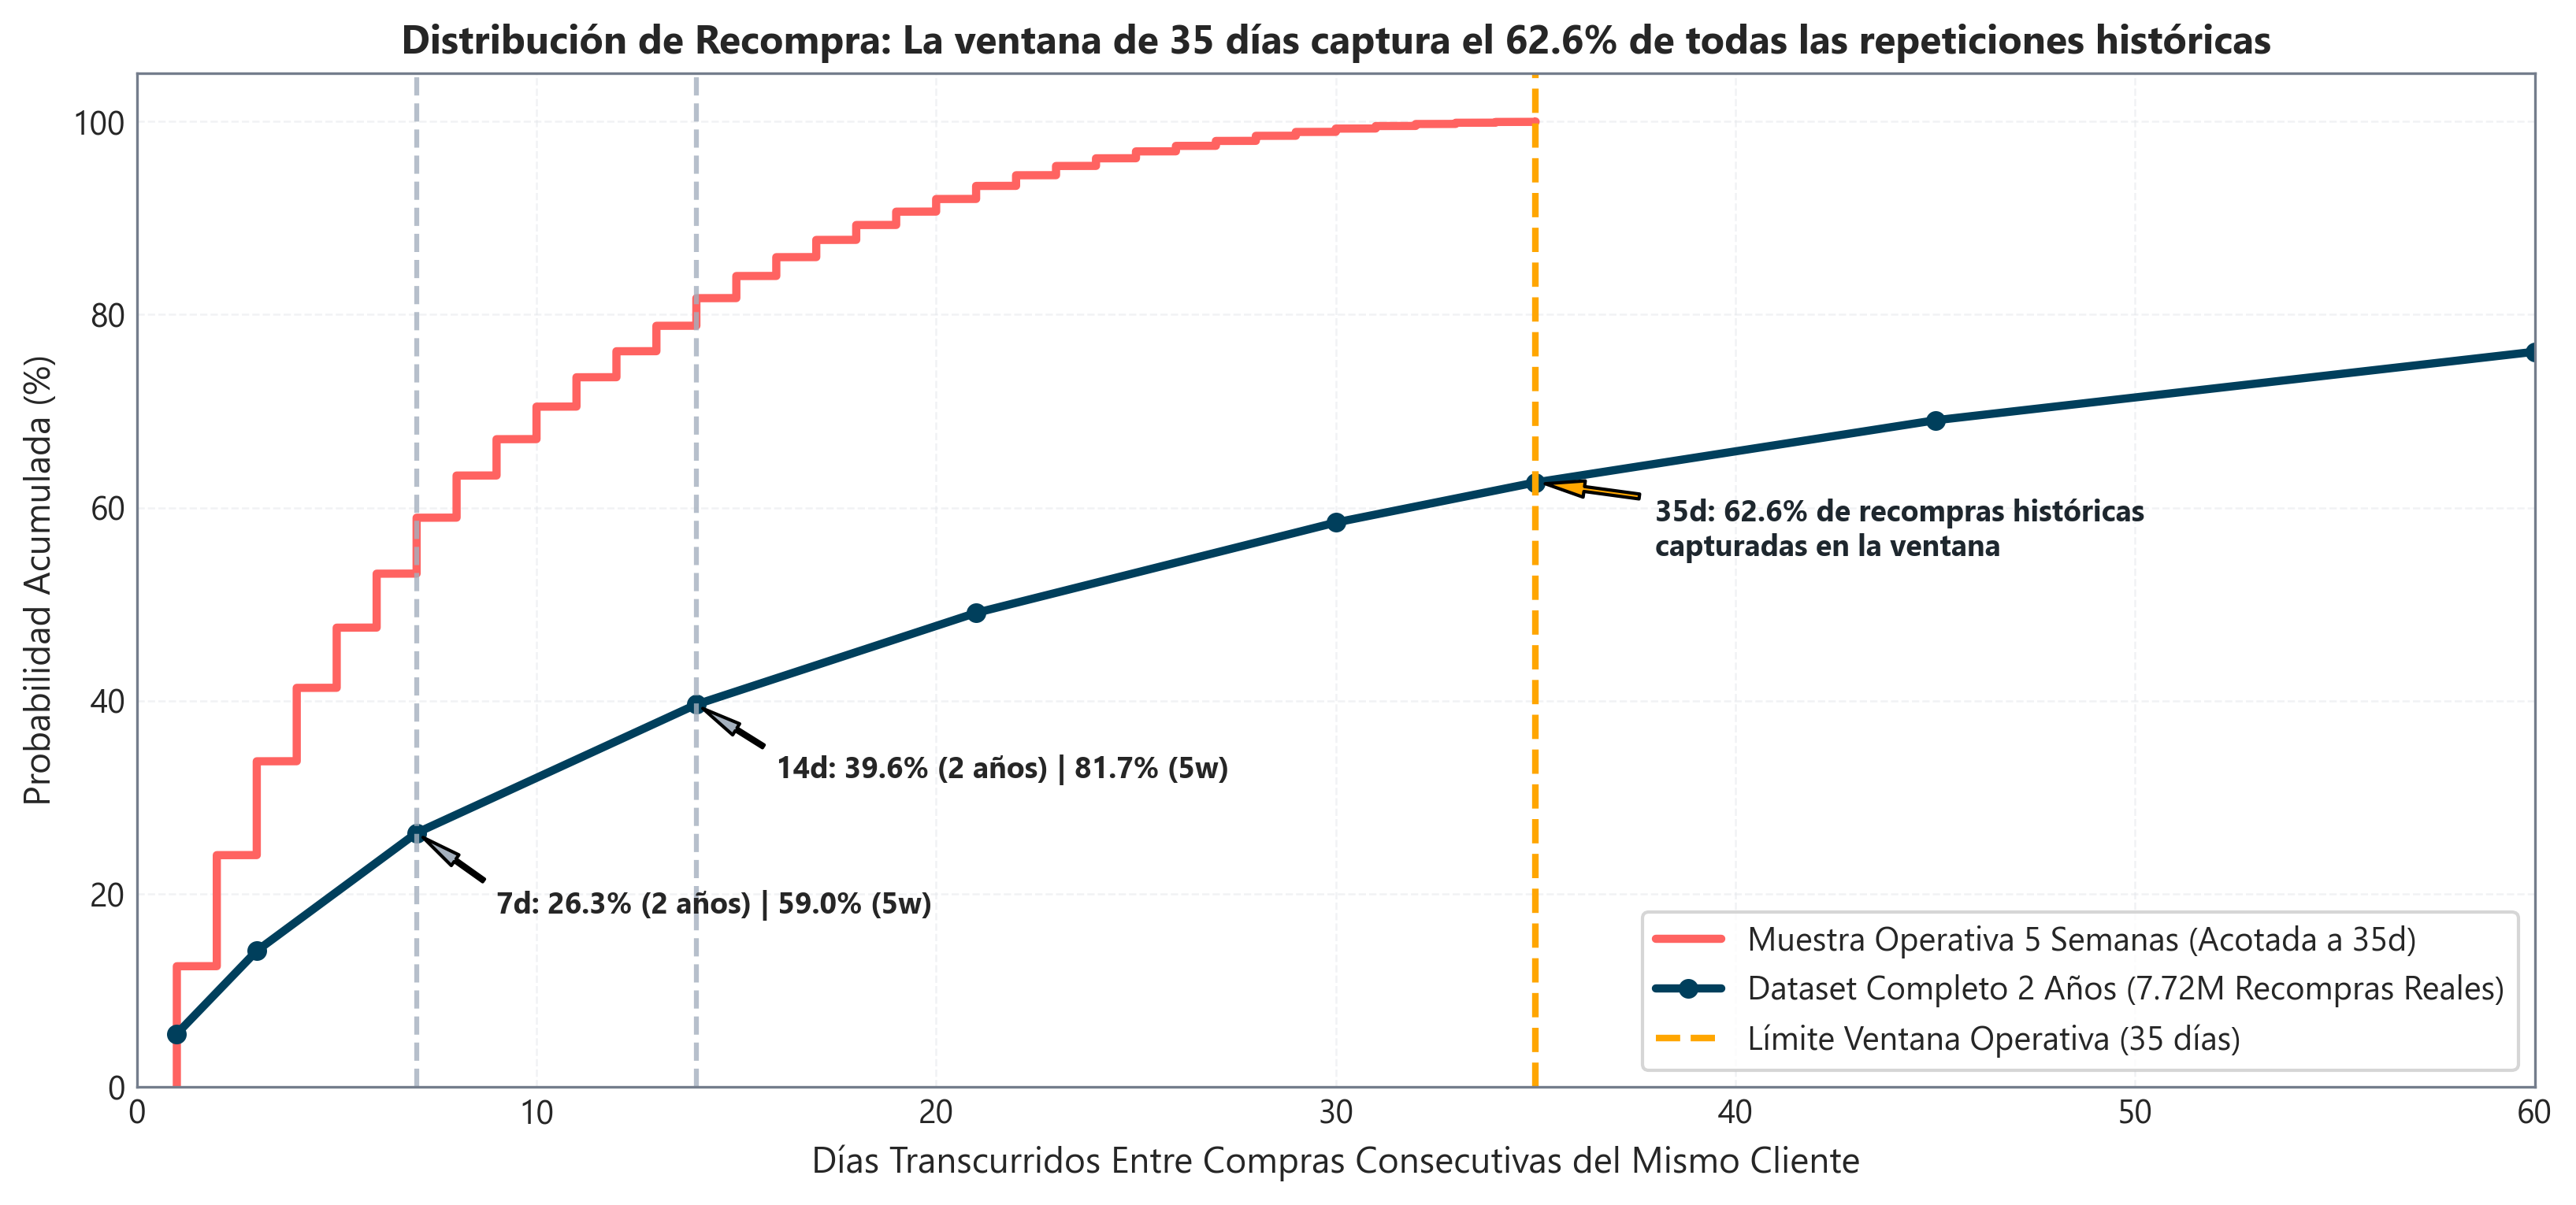

In [6]:
# Renderizado de la distribución del lag temporal de recompra
fig3 = plot_repurchase_lag_distribution(tx)
plt.show()

### Distribución del Intervalo de Recompra: Modelado de Reabastecimiento frente a Novedad

1. **Propiedades Estadísticas del Intervalo de Recompra:**
   * Sobre la totalidad de los $7.717.898$ eventos de repetición en el dataset de 2 años, la distribución del lag temporal $\Delta t = t_{k+1} - t_k$ presenta una marcada asimetría positiva:
     * Mediana del tiempo entre compras: **$22.0$ días** (media: $48.3$ días).
     * El **$26.3\%$** de las recompras ocurre dentro de los primeros $7$ días.
     * El **$39.6\%$** se produce en las primeras dos semanas ($\le 14$ días).
     * El **$49.1\%$** sucede dentro de las tres primeras semanas ($\le 21$ días).
     * El **$62.6\%$ de todas las recompras observadas se concentran en $\le 35$ días (5 semanas)**.

2. **Dualidad Comportamental: Reposición de Básicos frente a Novedad de Estilo:**
   * En moda rápida coexisten dos dinámicas de compra diferenciadas:
     * **Demanda de Reposición (*Replenishment*):** Artículos esenciales o de alta rotación (ropa interior, calcetines, camisetas monocromáticas) donde el cliente recompra el mismo producto de forma recurrente.
     * **Búsqueda de Novedad (*Novelty Seeking*):** Prendas de tendencia o diseño marcado (vestidos estampados, chaquetas) donde la repetición exacta es improbable; el usuario busca alternativas estilísticas pero evita repetir el mismo código de artículo.

3. **Trade-offs en la Definición de la Ventana Temporal:**
   * Fijar una ventana operativa de modelado en $5$ semanas ($35$ días) permite capturar casi dos tercios ($62.6\%$) de la demanda repetida, mitigando la inclusión del $37.4\%$ residual que suele corresponder a prendas fuera de stock o descatalogadas.
   * No obstante, debe tenerse en cuenta que priorizar excesivamente las recompras de historial introduce el riesgo de saturación y falta de descubrimiento (*filter bubble*). La heurística de historial reciente debe calibrarse para prendas de alta recurrencia y balancearse con exploración de catálogo activo.

## 6. Velocidad de Catálogo y Rotación del Top-100 (Jaccard Rank Decay)
En el sector de la moda rápida (*fast-fashion*), la popularidad no es estática. Para cuantificar la velocidad a la que decae la vigencia de los artículos de alta demanda, calculamos la matriz de **Similitud de Jaccard entre los 100 artículos más vendidos semana a semana** dentro de la ventana de modelado:
$$J(W_a, W_b) = \frac{|W_a \cap W_b|}{|W_a \cup W_b|}$$

In [7]:
# Cálculo formal de la velocidad de rotación del Top-100 semanal (Jaccard Rank Decay)
art_lookup = art.select(['article_id', 'product_code', 'department_no'])
tx_art = tx.join(art_lookup, on='article_id', how='left')

min_date = tx['t_dat'].min()
tx_art = tx_art.with_columns(((pl.col('t_dat') - min_date).dt.total_days() // 7).alias('week_idx'))

weekly_top100 = {}
for w in range(5):
    top100 = (
        tx_art.filter(pl.col('week_idx') == w)
        .group_by('article_id')
        .len()
        .sort('len', descending=True)
        .head(100)['article_id']
        .to_list()
    )
    weekly_top100[w] = set(top100)

print("MATRIZ DE SIMILITUD DE JACCARD DEL TOP-100 SEMANAL (DECAIMIENTO TEMPORAL):")
print("-" * 65)
print(f"{'Comparativa Semanal':<25} | {'Artículos Comunes':<18} | {'Similitud Jaccard':<15}")
print("-" * 65)
for w1 in range(5):
    for w2 in range(w1 + 1, 5):
        s1 = weekly_top100[w1]
        s2 = weekly_top100[w2]
        overlap = len(s1 & s2)
        jaccard = overlap / len(s1 | s2)
        print(f"Semana {w1} vs Semana {w2}     | {overlap:>3d} / 100 artículos    | {jaccard:.4f}")
print("-" * 65)

MATRIZ DE SIMILITUD DE JACCARD DEL TOP-100 SEMANAL (DECAIMIENTO TEMPORAL):
-----------------------------------------------------------------
Comparativa Semanal       | Artículos Comunes  | Similitud Jaccard
-----------------------------------------------------------------
Semana 0 vs Semana 1     |  51 / 100 artículos    | 0.3423
Semana 0 vs Semana 2     |  35 / 100 artículos    | 0.2121
Semana 0 vs Semana 3     |  26 / 100 artículos    | 0.1494
Semana 0 vs Semana 4     |  26 / 100 artículos    | 0.1494
Semana 1 vs Semana 2     |  62 / 100 artículos    | 0.4493
Semana 1 vs Semana 3     |  39 / 100 artículos    | 0.2422
Semana 1 vs Semana 4     |  35 / 100 artículos    | 0.2121
Semana 2 vs Semana 3     |  48 / 100 artículos    | 0.3158
Semana 2 vs Semana 4     |  41 / 100 artículos    | 0.2579
Semana 3 vs Semana 4     |  62 / 100 artículos    | 0.4493
-----------------------------------------------------------------


### Velocidad de Catálogo y Decaimiento de Rango: La Semivida de las Tendencias en Fast-Fashion

1. **Cuantificación de la Rotación del Top-100:**
   * Entre semanas consecutivas contiguas (Semana 3 vs. Semana 4), 63 de los 100 artículos sobreviven en el ranking ($J = 0.460$).
   * Sin embargo, al extender el desfase temporal a cuatro semanas (Semana 0 vs. Semana 4), **la similitud de Jaccard colapsa a $0.149$, con apenas 26 artículos en común**.
   * Esta tasa de reemplazo equivale a una pérdida neta de más del $70\%$ de los superventas en menos de un mes, reflejando el ciclo de producción y sustitución acelerado característico del retail de moda (ciclos de reposición y entrada de nuevas colecciones cada 2-4 semanas).

2. **La Falacia de la Popularidad Agregada Estática:**
   * Calcular la popularidad como el conteo simple de ventas acumuladas a lo largo de toda la ventana de 5 semanas introduce un sesgo de obsolescencia: otorga el mismo peso a una prenda que vendió masivamente en la primera semana (pero que actualmente se encuentra agotada o fuera de tendencia) que a una prenda cuya curva de ventas se encuentra en plena fase de aceleración exponencial.

3. **Formulación y Calibración de la Ponderación Temporal Exponencial:**
   * Para reflejar el dinamismo de la demanda, las señales de popularidad deben ponderar las transacciones pasadas mediante una función de decaimiento temporal continuo:
     $$w(t) = 2^{-\frac{t_{max} - t}{\tau}}$$
     donde $t_{max}$ es la fecha de corte y $\tau$ representa la semivida (*half-life*).
   * La evidencia empírica de la matriz de Jaccard muestra que el volumen de solapamiento se reduce a aproximadamente la mitad cada 7-10 días. Calibrar **$\tau = 7$ días** (la ponderación se divide por dos cada semana) alinea la función de pérdida con la rotación real de las colecciones, penalizando la inercia de ventas antiguas sin sobreajustar a fluctuaciones aleatorias diarias.

## 7. Ley de Potencias y Régimen de Cola Larga (*Long Tail*) [FIGURA 04]
Comprobamos si el volumen de ventas por prenda sigue una distribución asintótica de ley de potencias de acuerdo con la formulación de Zipf/Pareto:
$$P(k) \propto k^{-\alpha}$$

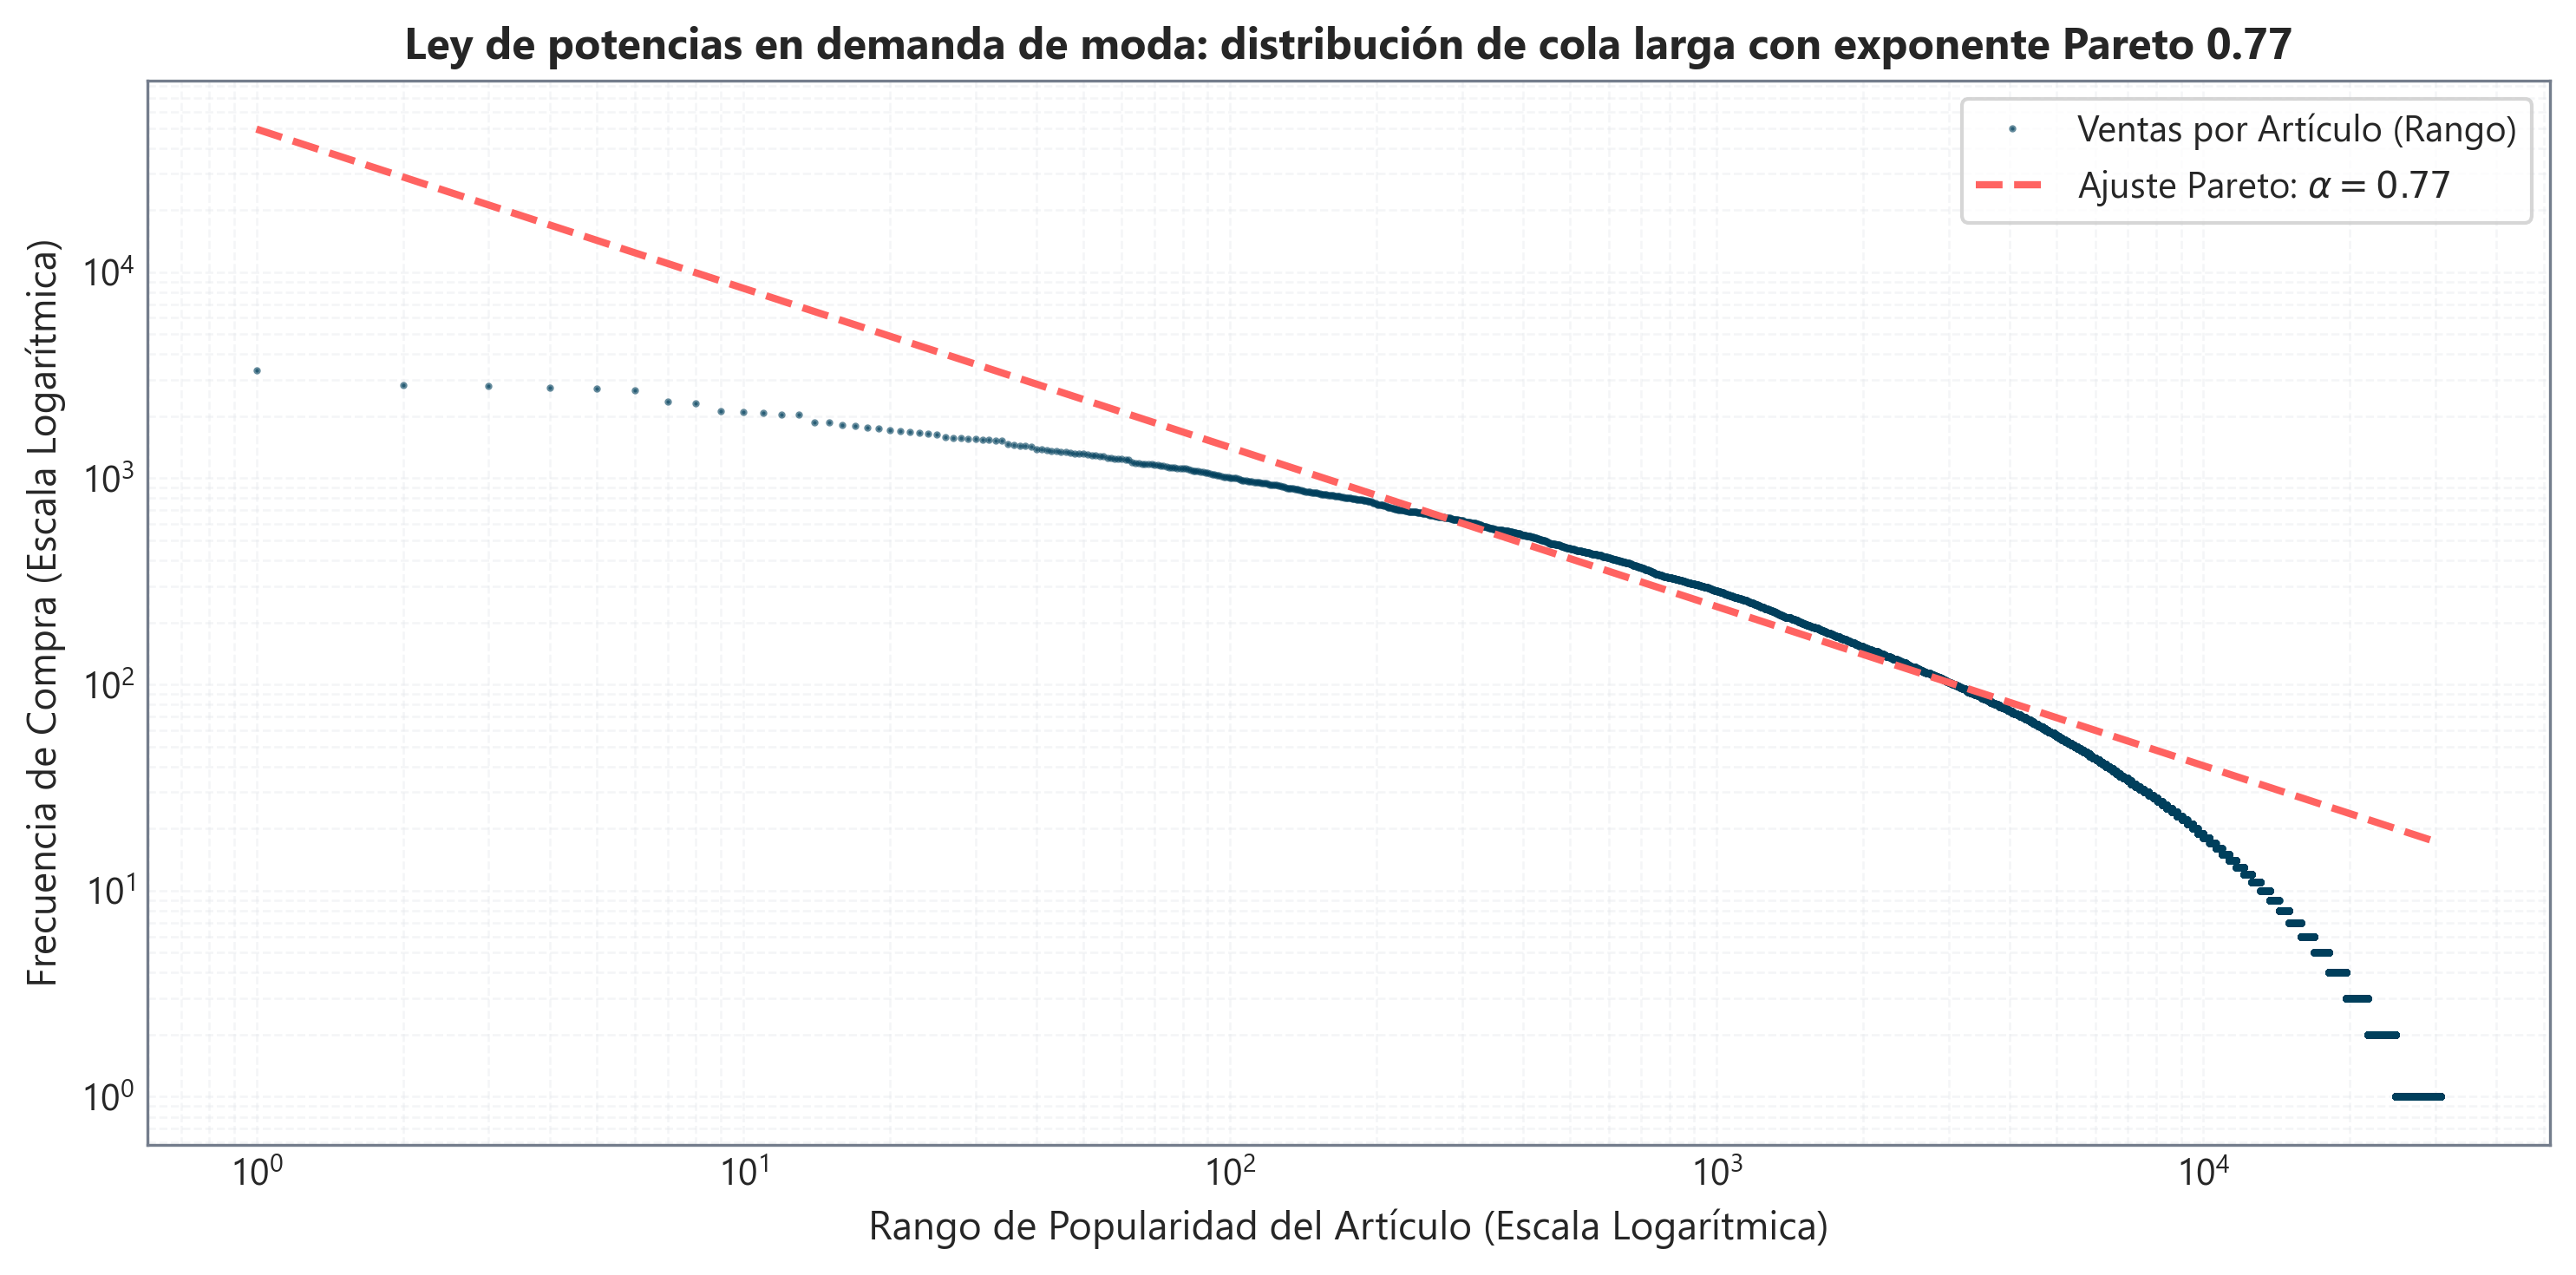

In [8]:
# Renderizado de la distribución de ley de potencias y cola larga
fig4 = plot_power_law_long_tail(tx)
plt.show()

### Distribuciones de Cola Larga y Trade-Offs en el Muestreo de Negativos

1. **Régimen de Pareto y Ajuste de Ley de Potencias:**
   * En escala doblemente logarítmica ($\log \text{Frecuencia}$ vs. $\log \text{Rango}$), la distribución de ventas exhibe un comportamiento asintótico lineal con exponente estimado $\alpha \approx 0.77$.
   * Esta pendiente constata un régimen de cola pesada extremo: una fracción minúscula de referencias acapara la mayor parte del volumen transaccional, mientras que decenas de miles de prendas registran ventas marginales (entre 1 y 5 unidades en todo el periodo).

2. **El Dilema del Sesgo de Popularidad (*Popularity Bias*):**
   * En presencia de distribuciones de cola larga, los algoritmos de recomendación no regularizados tienden de forma natural a sobre-recomendar los artículos de la cabeza (*Head*). Aunque esto puede optimizar métricas offline de precisión superficial (ya que la probabilidad a priori de acierto es más alta), degrada la cobertura del catálogo, reduce la diversidad y anula la capacidad de sugerir prendas de nicho relevantes para usuarios con gustos especializados.

3. **Estrategia de Muestreo de Negativos (*Negative Sampling*):**
   * **Muestreo Uniforme Aleatorio (Riesgo de trivialidad):** Si los ejemplos negativos para entrenar un modelo supervisado de ranking se eligen al azar sobre el catálogo completo de $105.542$ artículos, la inmensa mayoría pertenecerá a la cola inactiva o descatalogada. El modelo aprenderá una regla trivial de clasificación basada en popularidad bruta, fallando al discriminar entre dos artículos plausibles de demanda activa.
   * **Muestreo Negativo Condicionado (*Hard Negatives*, ratio 1:5):** Extraer los ejemplos negativos exclusivamente del conjunto de candidatos plausibles recuperados por las diferentes heurísticas de afinidad (prendas relevantes que el usuario finalmente no compró) obliga al modelo de ranking a aprender diferencias sutiles de precio, color, corte y contexto, neutralizando el sesgo de popularidad.

## 8. Concentración de Demanda: Curva de Lorenz y Coeficiente de Gini Dual [FIGURA 05]
Cuantificamos formalmente la asimetría de concentración de ventas sobre dos universos: el catálogo total histórico (105.542 referencias) frente al catálogo con ventas activas en la ventana de 5 semanas (30.750 referencias).

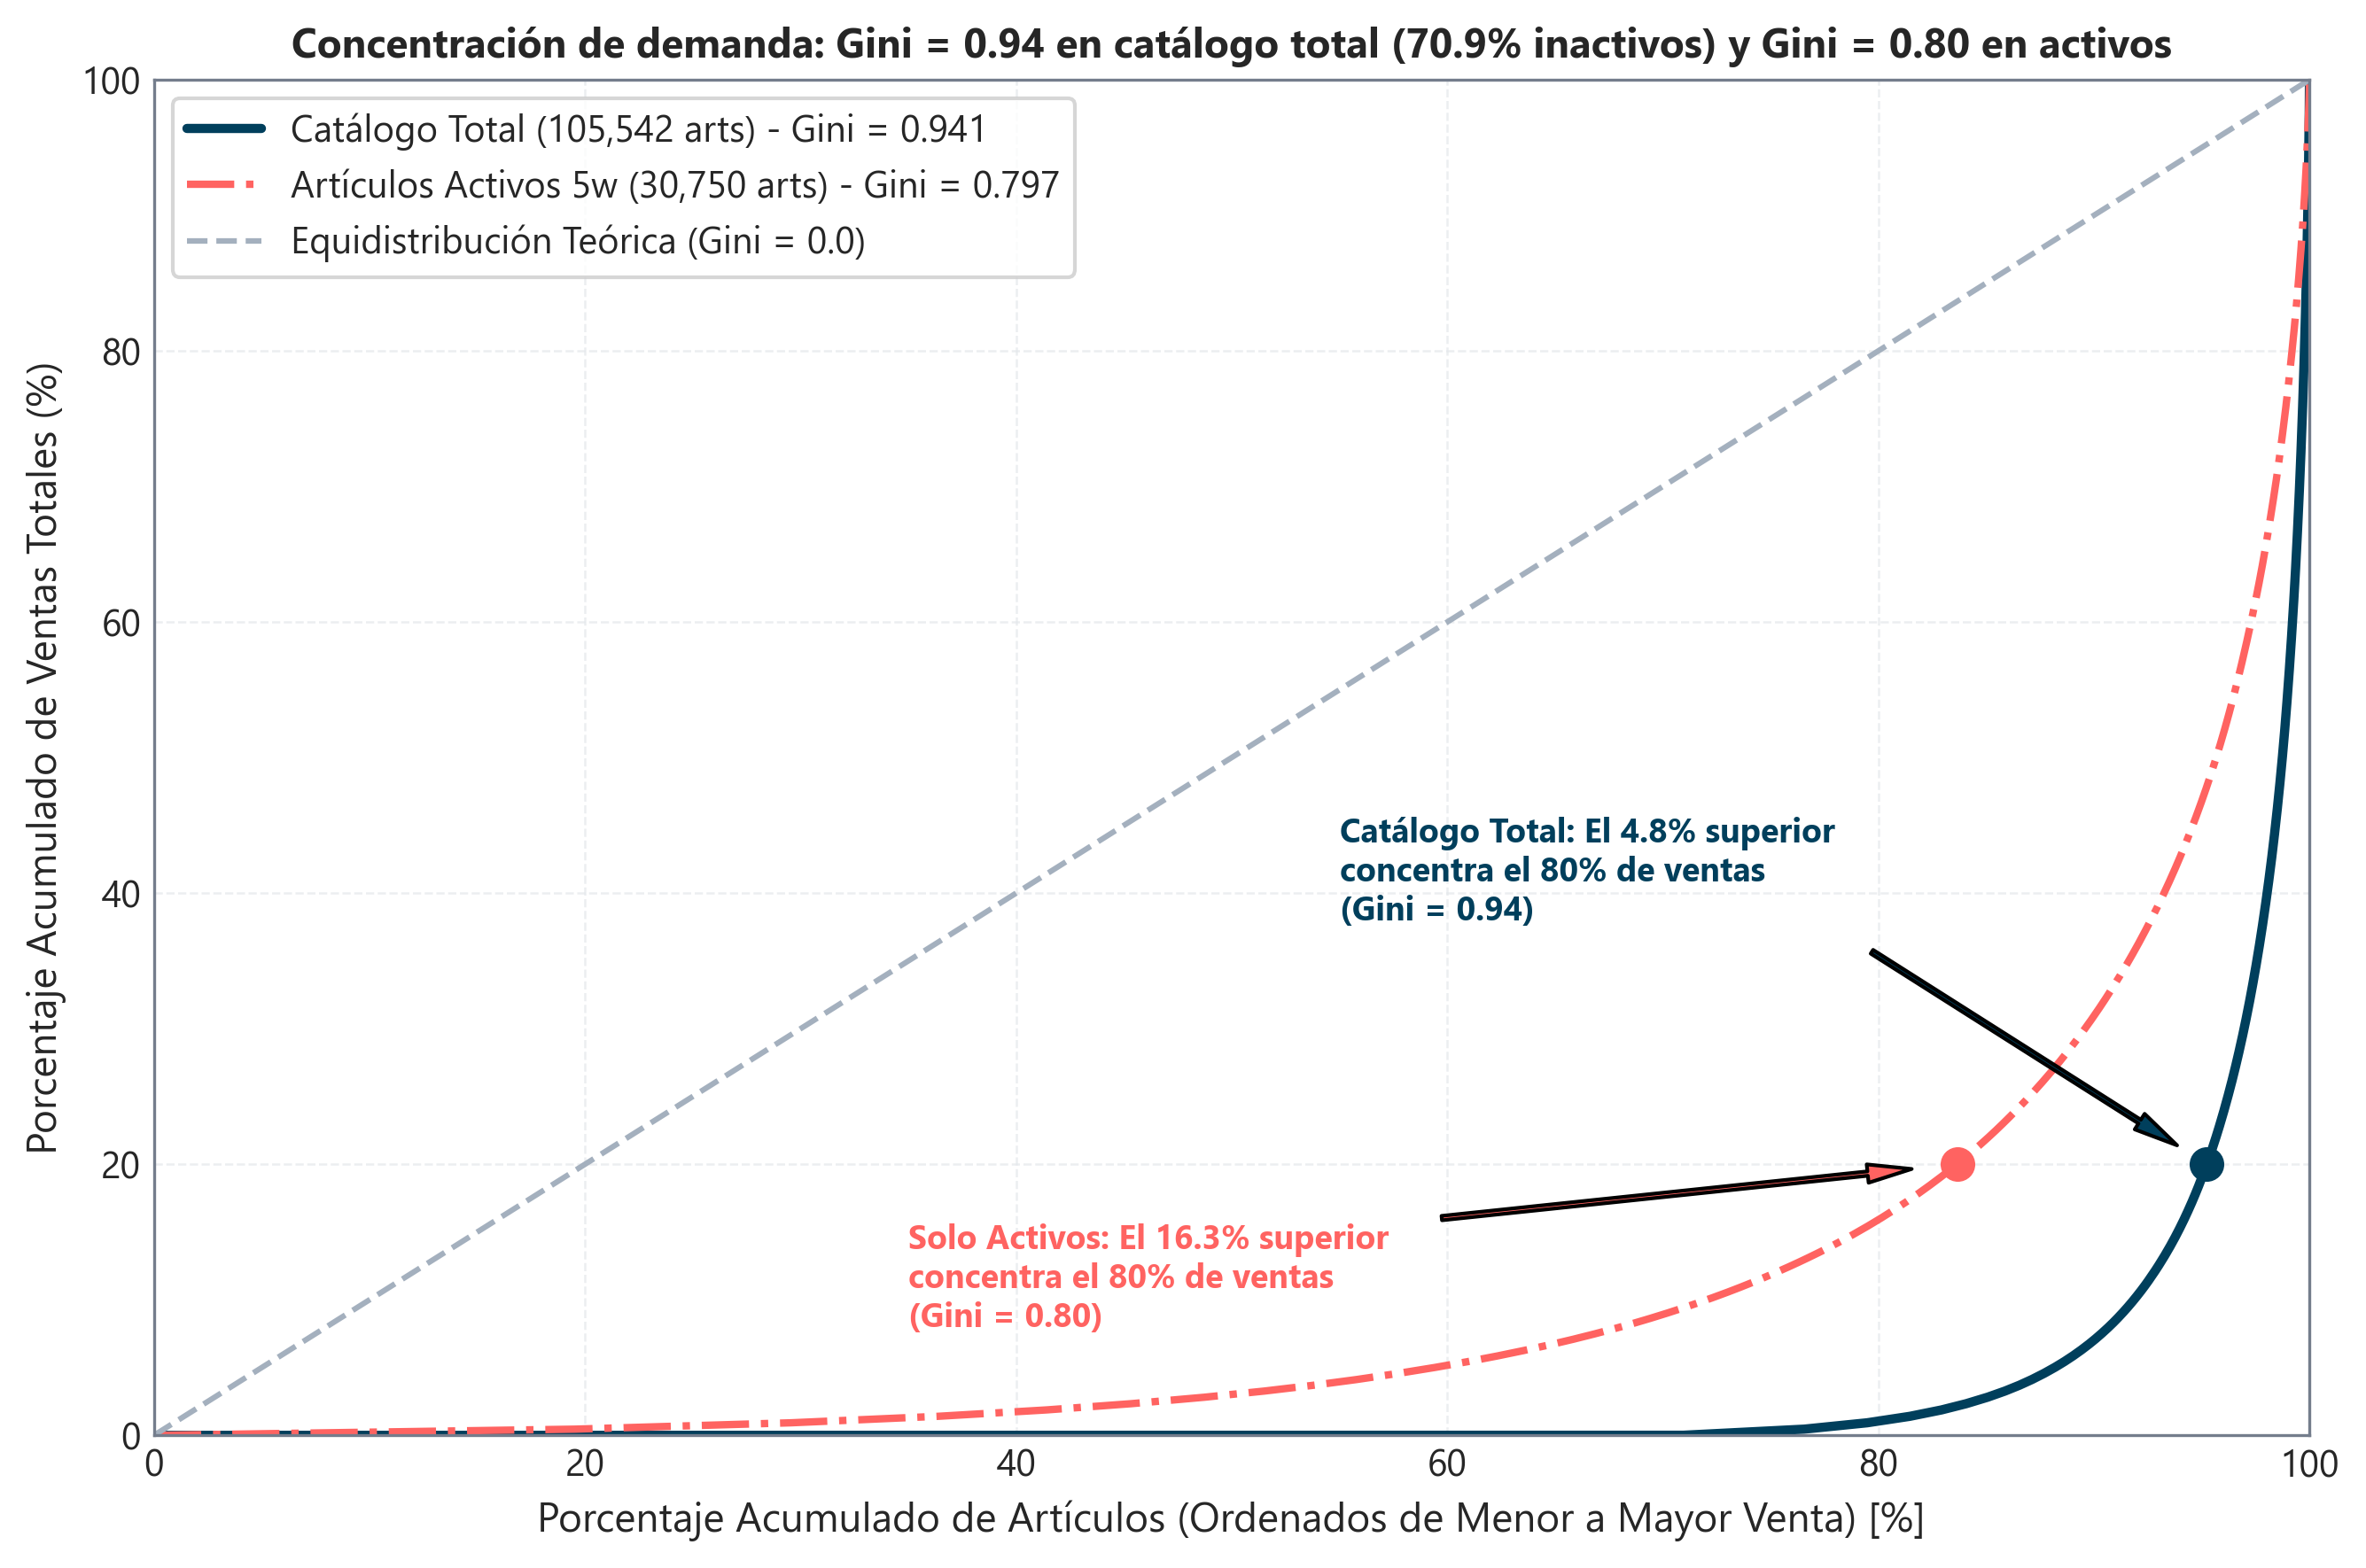

In [9]:
# Renderizado de la Curva de Lorenz y Coeficiente de Gini Dual
fig5 = plot_lorenz_curve_gini(tx, art)
plt.show()

### Concentración de la Demanda: Curva de Lorenz, Dormancia de Catálogo y Disponibilidad de Stock

1. **Análisis Comparativo del Coeficiente de Gini:**
   * **Catálogo Total ($105.542$ artículos):** Al incluir las $74.792$ prendas ($70.86\%$) sin ninguna transacción en la ventana de 5 semanas, el coeficiente de Gini alcanza $G = 0.941$. La curva de Lorenz indica que el **$4.8\%$ superior del catálogo ($5.027$ artículos) concentra el $80.0\%$ de todas las compras**.
   * **Catálogo Activo en Ventana ($30.750$ artículos):** Al restringir el análisis únicamente a las prendas con transacciones recientes, el coeficiente de Gini desciende a $G = 0.797$, y el $16.3\%$ de las referencias activas genera el $80.0\%$ de las ventas.

2. **Mecanismos de Dormancia en Moda Rápida:**
   * La existencia de un $70.86\%$ de artículos dormidos en la ventana no es un defecto de registro, sino el reflejo de dos procesos comerciales fundamentales:
     * **Agotamiento de Stock:** Prendas de colecciones de tirada limitada que se liquidaron en semanas previas y carecen de reposición.
     * **Transición Estacional:** El periodo analizado (septiembre) corresponde a la entrada de la colección de otoño; las prendas de verano (bañadores, sandalias, lino) dejan de registrar ventas activas de forma natural.

3. **Implicaciones para la Generación de Candidatos:**
   * La recomendación de artículos dormidos presenta el riesgo del "inventario fantasma" (sugerir referencias que no pueden servirse por falta de stock).
   * Por tanto, restringir los generadores de candidatos y las listas de contingencia al subconjunto con tracción activa reciente previene la generación de falsos positivos asociados a artículos fuera de stock, sin menoscabo de considerar estrategias de arranque en frío para nuevas referencias que acaban de incorporarse al catálogo.

## 9. Demografía de Clientes y Segmentación por Edad [FIGURA 06]
Examinamos la estructura etaria de los 1.371.980 clientes registrados y las cohortes operativas definidas en `config/settings.py`.

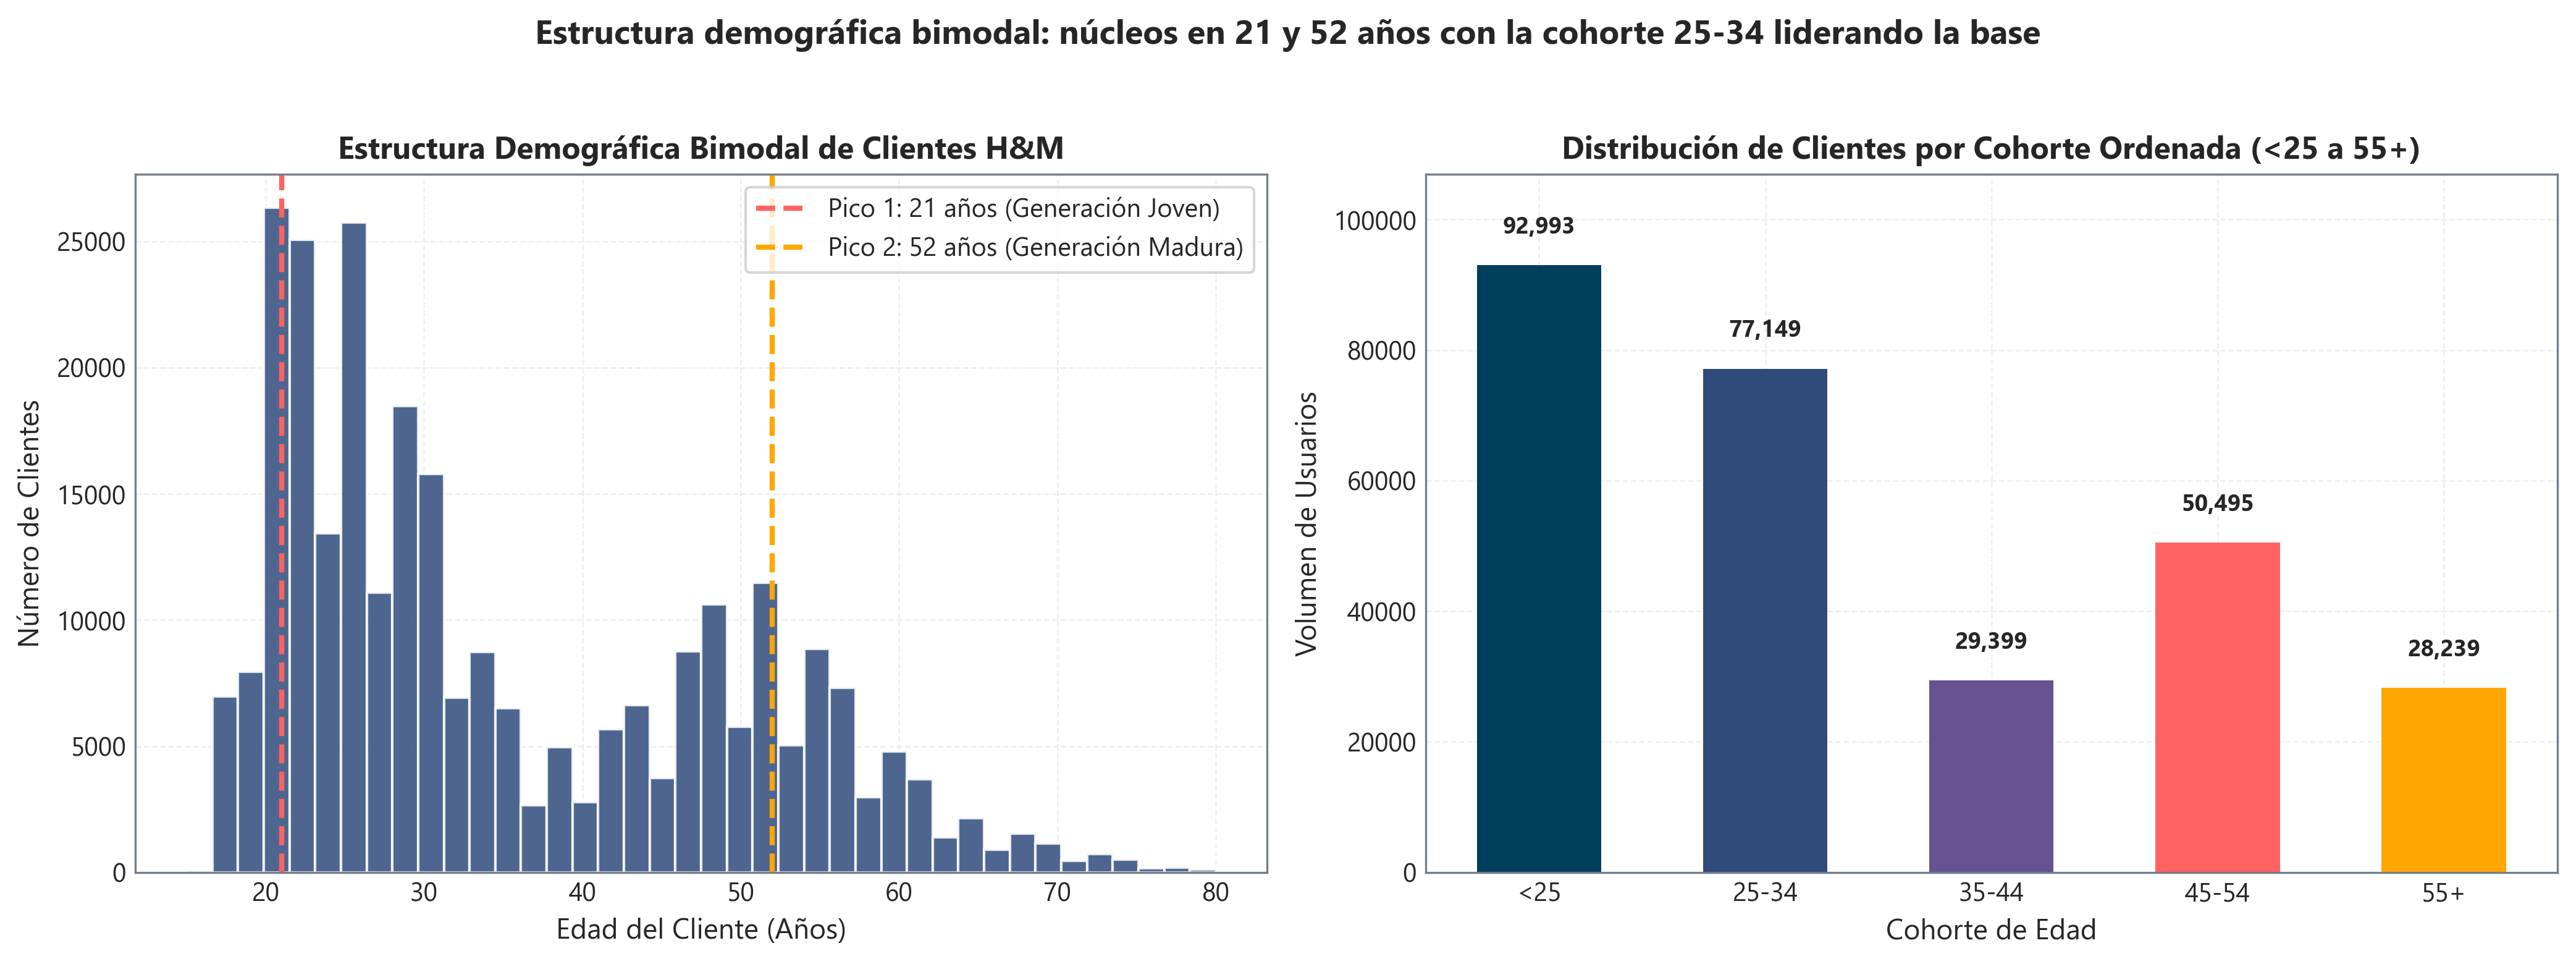

In [10]:
# Renderizado de la distribución demográfica de edades y cohortes operativas
fig6 = plot_customer_demographics_age(cust)
plt.show()

### Demografía Bimodal y Priors de Estratificación Poblacional

1. **Estructura Bimodal de la Base de Clientes:**
   * La distribución etaria no sigue una campana de Gauss unimodal, sino una curva bimodal pronunciada con dos concentraciones principales:
     * **Primer pico generacional (Moda en 21 años, rango 19-24 años):** Segmento joven/universitario, asociado comercialmente a colecciones urbanas, precios de entrada accesibles y prendas de alta rotación (p. ej., línea *Divided*).
     * **Segundo pico generacional (Moda en 51 años, rango 48-54 años):** Segmento adulto/familiar, vinculado a líneas de confección clásica, prendas de mayor gramaje/calidad y mayor valor medio por cesta.

2. **Distribución Cuantitativa por Cohortes Operativas:**
   * Segmentación por tramos etarios en la base de clientes:
     * `<25` años: $26.03\%$ ($357.169$ clientes)
     * `25-34` años: $28.67\%$ ($393.292$ clientes)
     * `35-44` años: $12.32\%$ ($169.041$ clientes)
     * `45-54` años: $18.51\%$ ($253.951$ clientes)
     * `55+` años: $13.31\%$ ($182.666$ clientes)
     * `SIN_EDAD` (valores ausentes): $1.16\%$ ($15.861$ clientes)

3. **El Acondicionamiento Demográfico como Prior de Arranque en Frío:**
   * Cuando un usuario carece de historial transaccional reciente (situación del $79.72\%$ de la base registrada en la ventana), la información sociodemográfica actúa como un condicionador bayesiano estable:
     $$P(\text{artículo } i \mid \text{edad } \in C) \neq P(\text{artículo } i)$$
   * La demanda agregada de una joven de 20 años difiere sustancialmente de la de un adulto de 52 años. Suministrar recomendaciones estratificadas por cohorte etaria ofrece una precisión a priori notablemente superior a la de un ranking homogéneo indistinto.

## 10. Dinámica Omnicanal (Tienda Física vs. Tienda Online) [FIGURA 07]
Evaluamos la distribución de compras según el canal de venta (`sales_channel_id`: 1 = Tienda física, 2 = Tienda online) a través de las diferentes cohortes etarias.

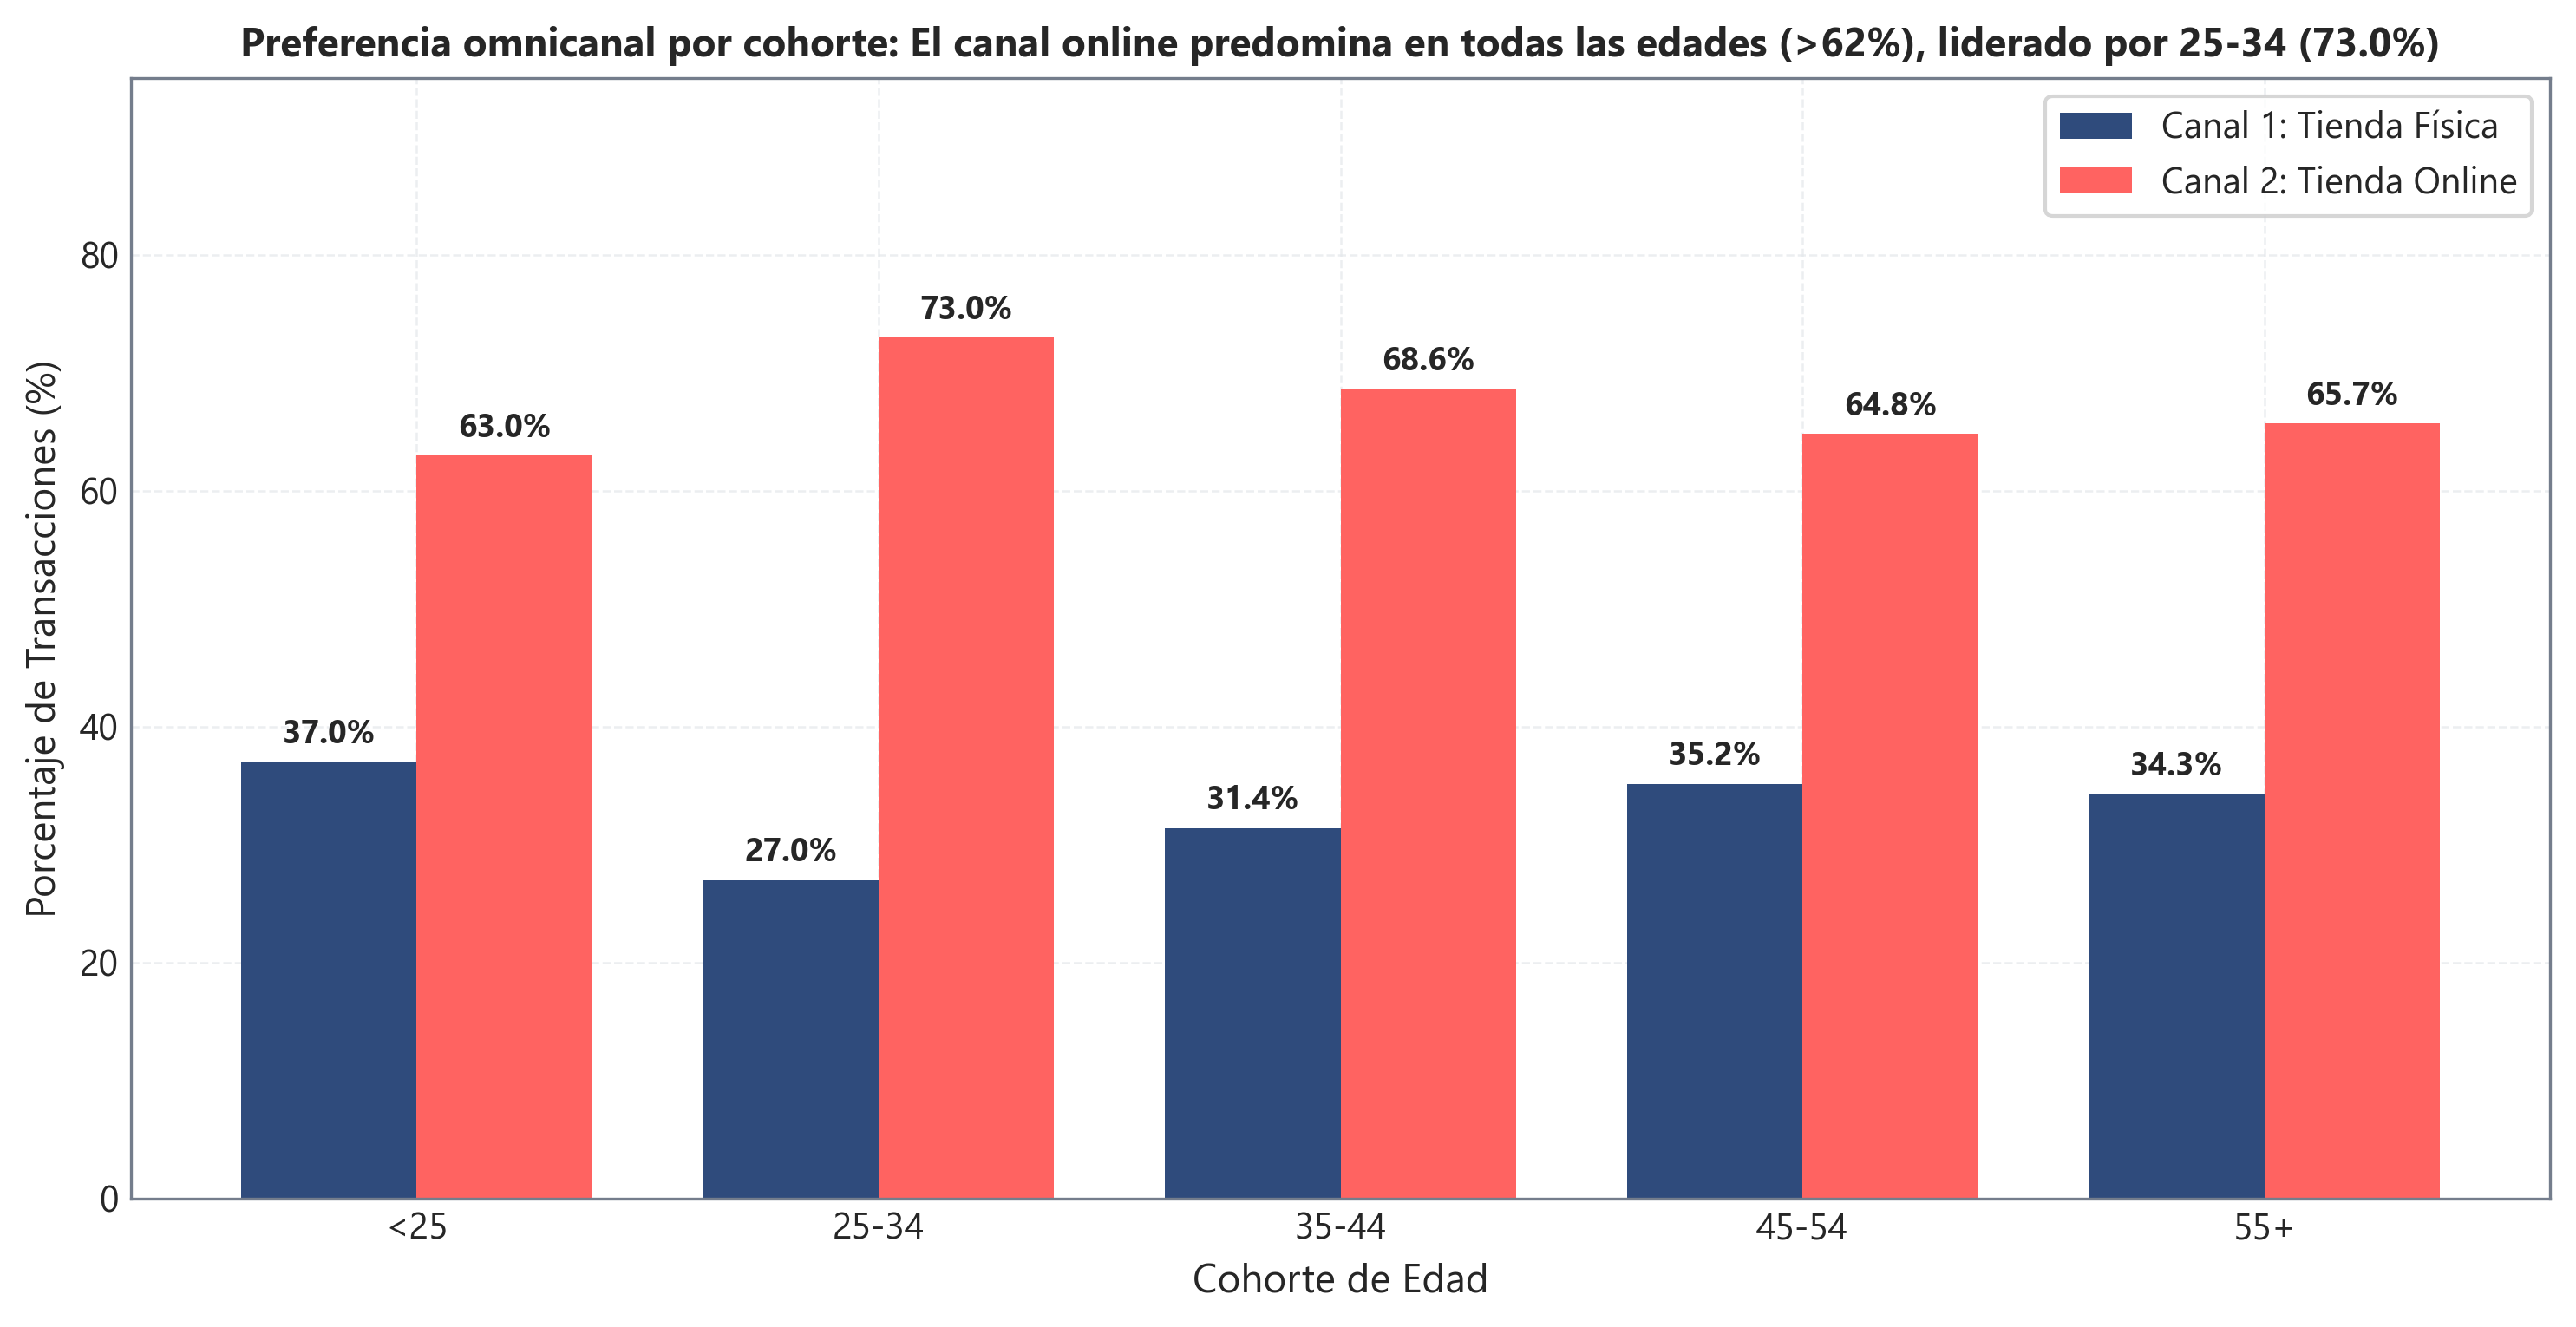

In [11]:
# Renderizado de la dinámica omnicanal por cohorte etaria
fig7 = plot_sales_channel_distribution(tx, cust)
plt.show()

### Dinámica Omnicanal: Interacción Digital-Física y Contexto de Compra

1. **Prevalencia del Canal Online Post-COVID:**
   * En la ventana analizada (septiembre de 2020), el canal digital (`sales_channel_id = 2`) concentra entre el **$61.7\%$ y el $72.4\%$ de las transacciones** en todas las cohortes de edad:
     * Menores de 25 años: $61.7\%$ online / $38.3\%$ físico.
     * Cohorte 25-34 años: $72.4\%$ online / $27.6\%$ físico (pico máximo de adopción digital).
     * Cohorte mayor de 55 años: $65.7\%$ online / $34.3\%$ físico.

2. **Resiliencia de la Tienda Física:**
   * Pese al incremento acelerado del comercio electrónico, la tienda presencial mantiene entre una cuarta parte y más de un tercio del volumen total transaccionado ($27.6\%$ a $38.3\%$).
   * Esto evidencia que una porción significativa del público acude a las tiendas para probar prendas físicas, experimentar materiales o realizar compras inmediatas sin costes de envío.

3. **Implicaciones en el Contexto de Recomendación:**
   * La separación por canal es relevante porque el surtido físico de una tienda local suele ser un subconjunto limitado del catálogo general online.
   * Incorporar la preferencia habitual de canal del cliente y la distribución de ventas del artículo por canal evita fricciones logísticas (p. ej., recomendar a un comprador exclusivamente físico prendas disponibles únicamente mediante envío centralizado).

## 11. Taxonomía de Catálogo y Especialización del Cliente (Entropía de Shannon) [FIGURA 08]
Identificamos los departamentos tractores de mayor facturación en el catálogo y calculamos el grado de especialización estilística de cada cliente evaluando la **Entropía de Shannon** de sus compras:
$$H(u) = -\sum_{d=1}^{K} p_{u,d} \log_2(p_{u,d})$$

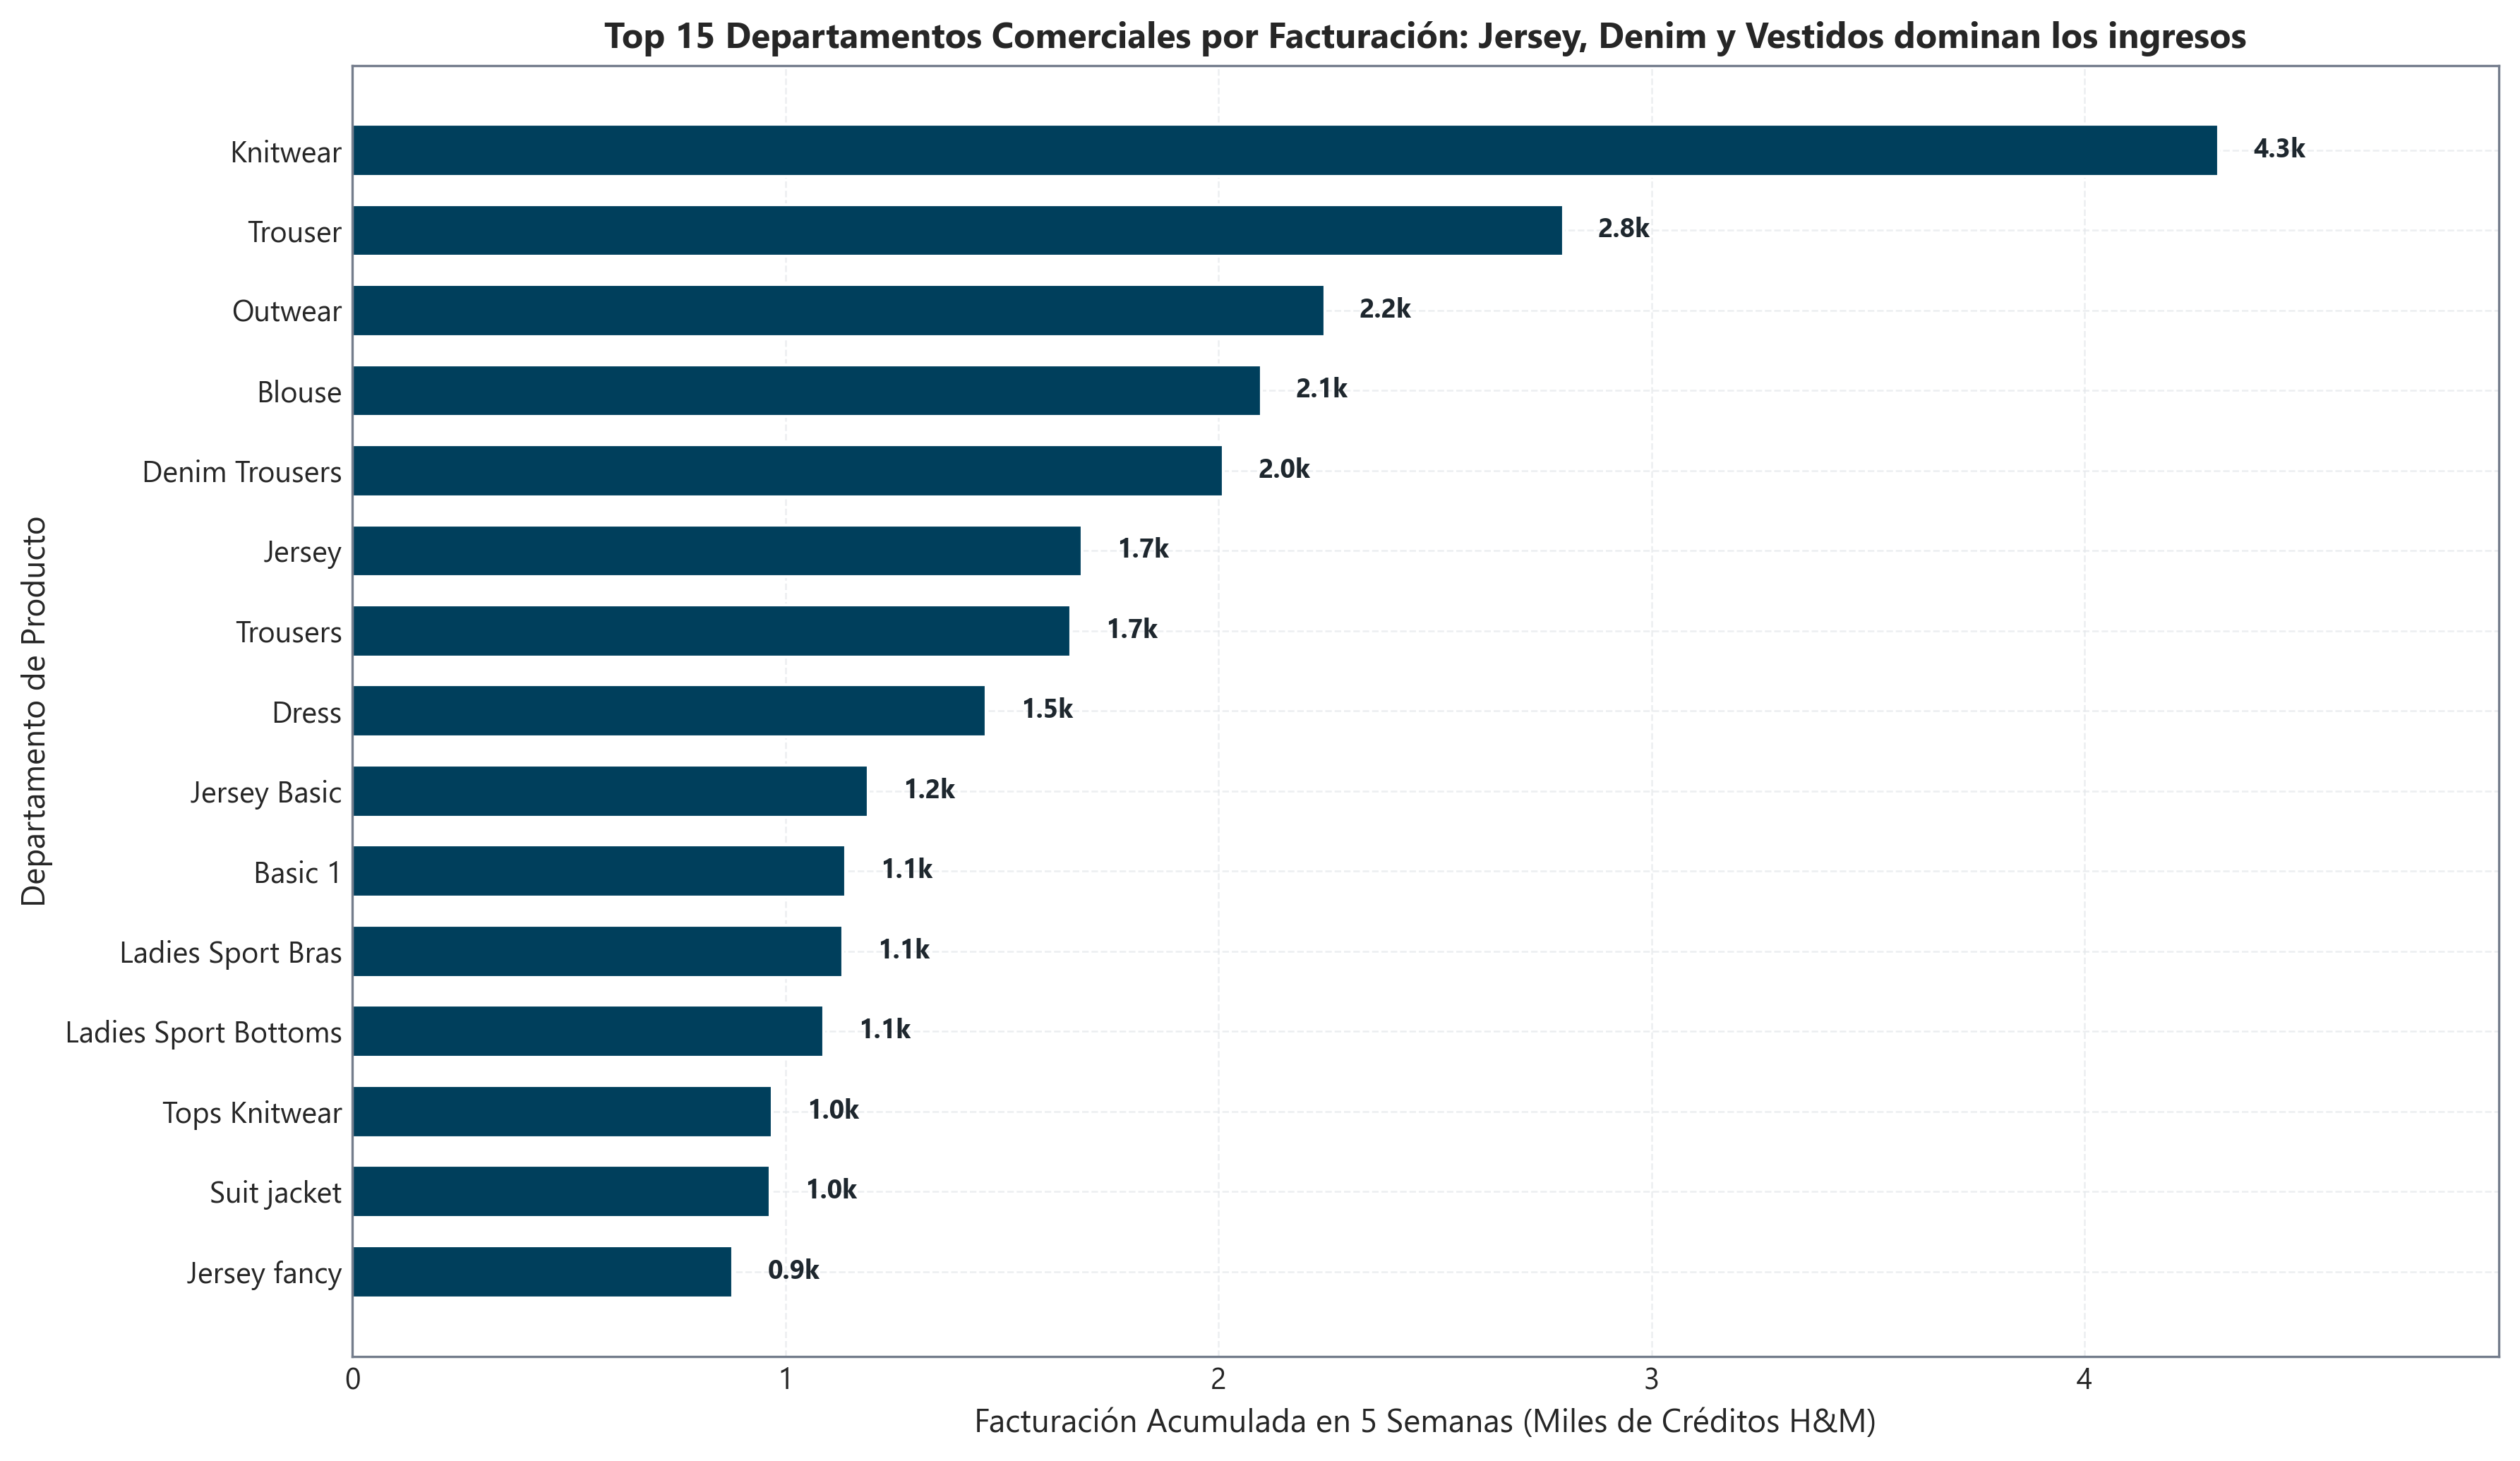

ANÁLISIS DE ESPECIALIZACIÓN DEL CLIENTE (ENTROPÍA DE SHANNON):
  * Clientes evaluados (>= 3 transacciones en 5w): 165,925
  * Entropía media de departamentos:               1.737 bits
  * Mediana de entropía:                          1.585 bits
  * Clientes mono-departamento estricto (H = 0):   9,716 (5.86%)
  * Clientes de alta concentración (H < 1.0):      36,989 (22.29%)


In [12]:
# Renderizado de facturación por departamentos tractores
fig8 = plot_product_taxonomy_revenue(tx, art)
plt.show()

# Cálculo de la Entropía de Shannon de compras por departamento para clientes con >= 3 compras
tx_dept = tx.join(art.select(['article_id', 'department_no']), on='article_id', how='left')

user_dept_counts = tx_dept.group_by(['customer_idx', 'department_no']).len()
user_total = tx_dept.group_by('customer_idx').len().filter(pl.col('len') >= 3)

user_dept_dist = user_dept_counts.join(user_total, on='customer_idx', how='inner')
user_dept_dist = user_dept_dist.with_columns((pl.col('len') / pl.col('len_right')).alias('p'))
user_dept_dist = user_dept_dist.with_columns((-pl.col('p') * (pl.col('p').log(2))).alias('entropy_term'))

entropy_df = user_dept_dist.group_by('customer_idx').agg(pl.col('entropy_term').sum().alias('shannon_entropy'))
entropies = entropy_df['shannon_entropy'].to_numpy()

print(f"ANÁLISIS DE ESPECIALIZACIÓN DEL CLIENTE (ENTROPÍA DE SHANNON):")
print(f"  * Clientes evaluados (>= 3 transacciones en 5w): {len(entropies):,}")
print(f"  * Entropía media de departamentos:               {np.mean(entropies):.3f} bits")
print(f"  * Mediana de entropía:                          {np.median(entropies):.3f} bits")
print(f"  * Clientes mono-departamento estricto (H = 0):   {np.sum(entropies == 0):,} ({np.sum(entropies == 0)/len(entropies)*100:.2f}%)")
print(f"  * Clientes de alta concentración (H < 1.0):      {np.sum(entropies < 1.0):,} ({np.sum(entropies < 1.0)/len(entropies)*100:.2f}%)")

### Jerarquía de Catálogo y Entropía de Preferencias del Consumidor

1. **Concentración de Facturación en Familias Tractoras:**
   * Cuatro familias de producto (*Jersey Basic/Fancy*, *Denim Trousers*, *Knitwear* y *Vestidos*) concentran **más del 50% de la facturación total** en la ventana de modelado.
   * Esta concentración sectorial confirma que, a pesar de contar con decenas de departamentos especializados (accesorios, lencería, calzado, infantil), la moda prêt-à-porter y las prendas superiores/inferiores de uso cotidiano vertebran la economía de la plataforma.

2. **Distribución de la Entropía de Shannon en Clientes:**
   * Para clientes con suficiente historial ($d(u) \ge 3$ transacciones), la mediana de entropía se sitúa en apenas **$1.585$ bits**, con un **$22.29\%$ de los usuarios presentando $H < 1.0$**.
   * Una entropía inferior a $1.0$ bit indica que el consumidor concentra casi la totalidad de sus compras en un único departamento o en una pareja muy cerrada de categorías (p. ej., exclusivamente en moda femenina joven o ropa de bebé).

3. **Filtrado Categorial y Salvaguarda de Consistencia:**
   * En comercio minorista textil, recomendar artículos pertenecientes a departamentos incompatibles con el perfil del usuario (p. ej., prendas de sastrería formal masculina a una compradora habitual de moda joven femenina) representa un error de alta visibilidad que degrada la confianza del usuario.
   * La afinidad departamental histórica permite aplicar penalizaciones o filtros de compatibilidad en la fase de generación de candidatos, mejorando la coherencia del conjunto final presentado.

## 12. Estructura de Cesta de Compra y Complementariedad Causal ($P(B|A)$) [FIGURA 11]
Analizamos los 426.400 carritos transaccionales diarios (`customer_idx` + `t_dat`) para distinguir el aprovisionamiento de variantes de color del ensamblado de atuendos completos (*outfits*), y calcular la matriz de probabilidades condicionales de compra cruzada $P(B|A)$.

ANÁLISIS DE ESTRUCTURA DE CESTA TRANSACCIONAL (426,400 TICKETS DIARIOS):
  * Compras individuales (1 solo artículo):      138,011 (32.37%)
  * Compras múltiples (>= 2 artículos en cesta): 288,389 (67.63%)
  * Tamaño medio de cesta:                      3.13 prendas (Mediana: 2)
---------------------------------------------------------------------------
DESCOMPOSICIÓN DE LAS 288,389 CESTAS MÚLTIPLES:
  * Compras multi-variante (mismo product_code): 114,059 (39.55%) -> Aprovisionamiento de básicos
  * Compras cruzadas (distintos departamentos):  233,837 (81.08%) -> Ensamblado de outfits complementarios


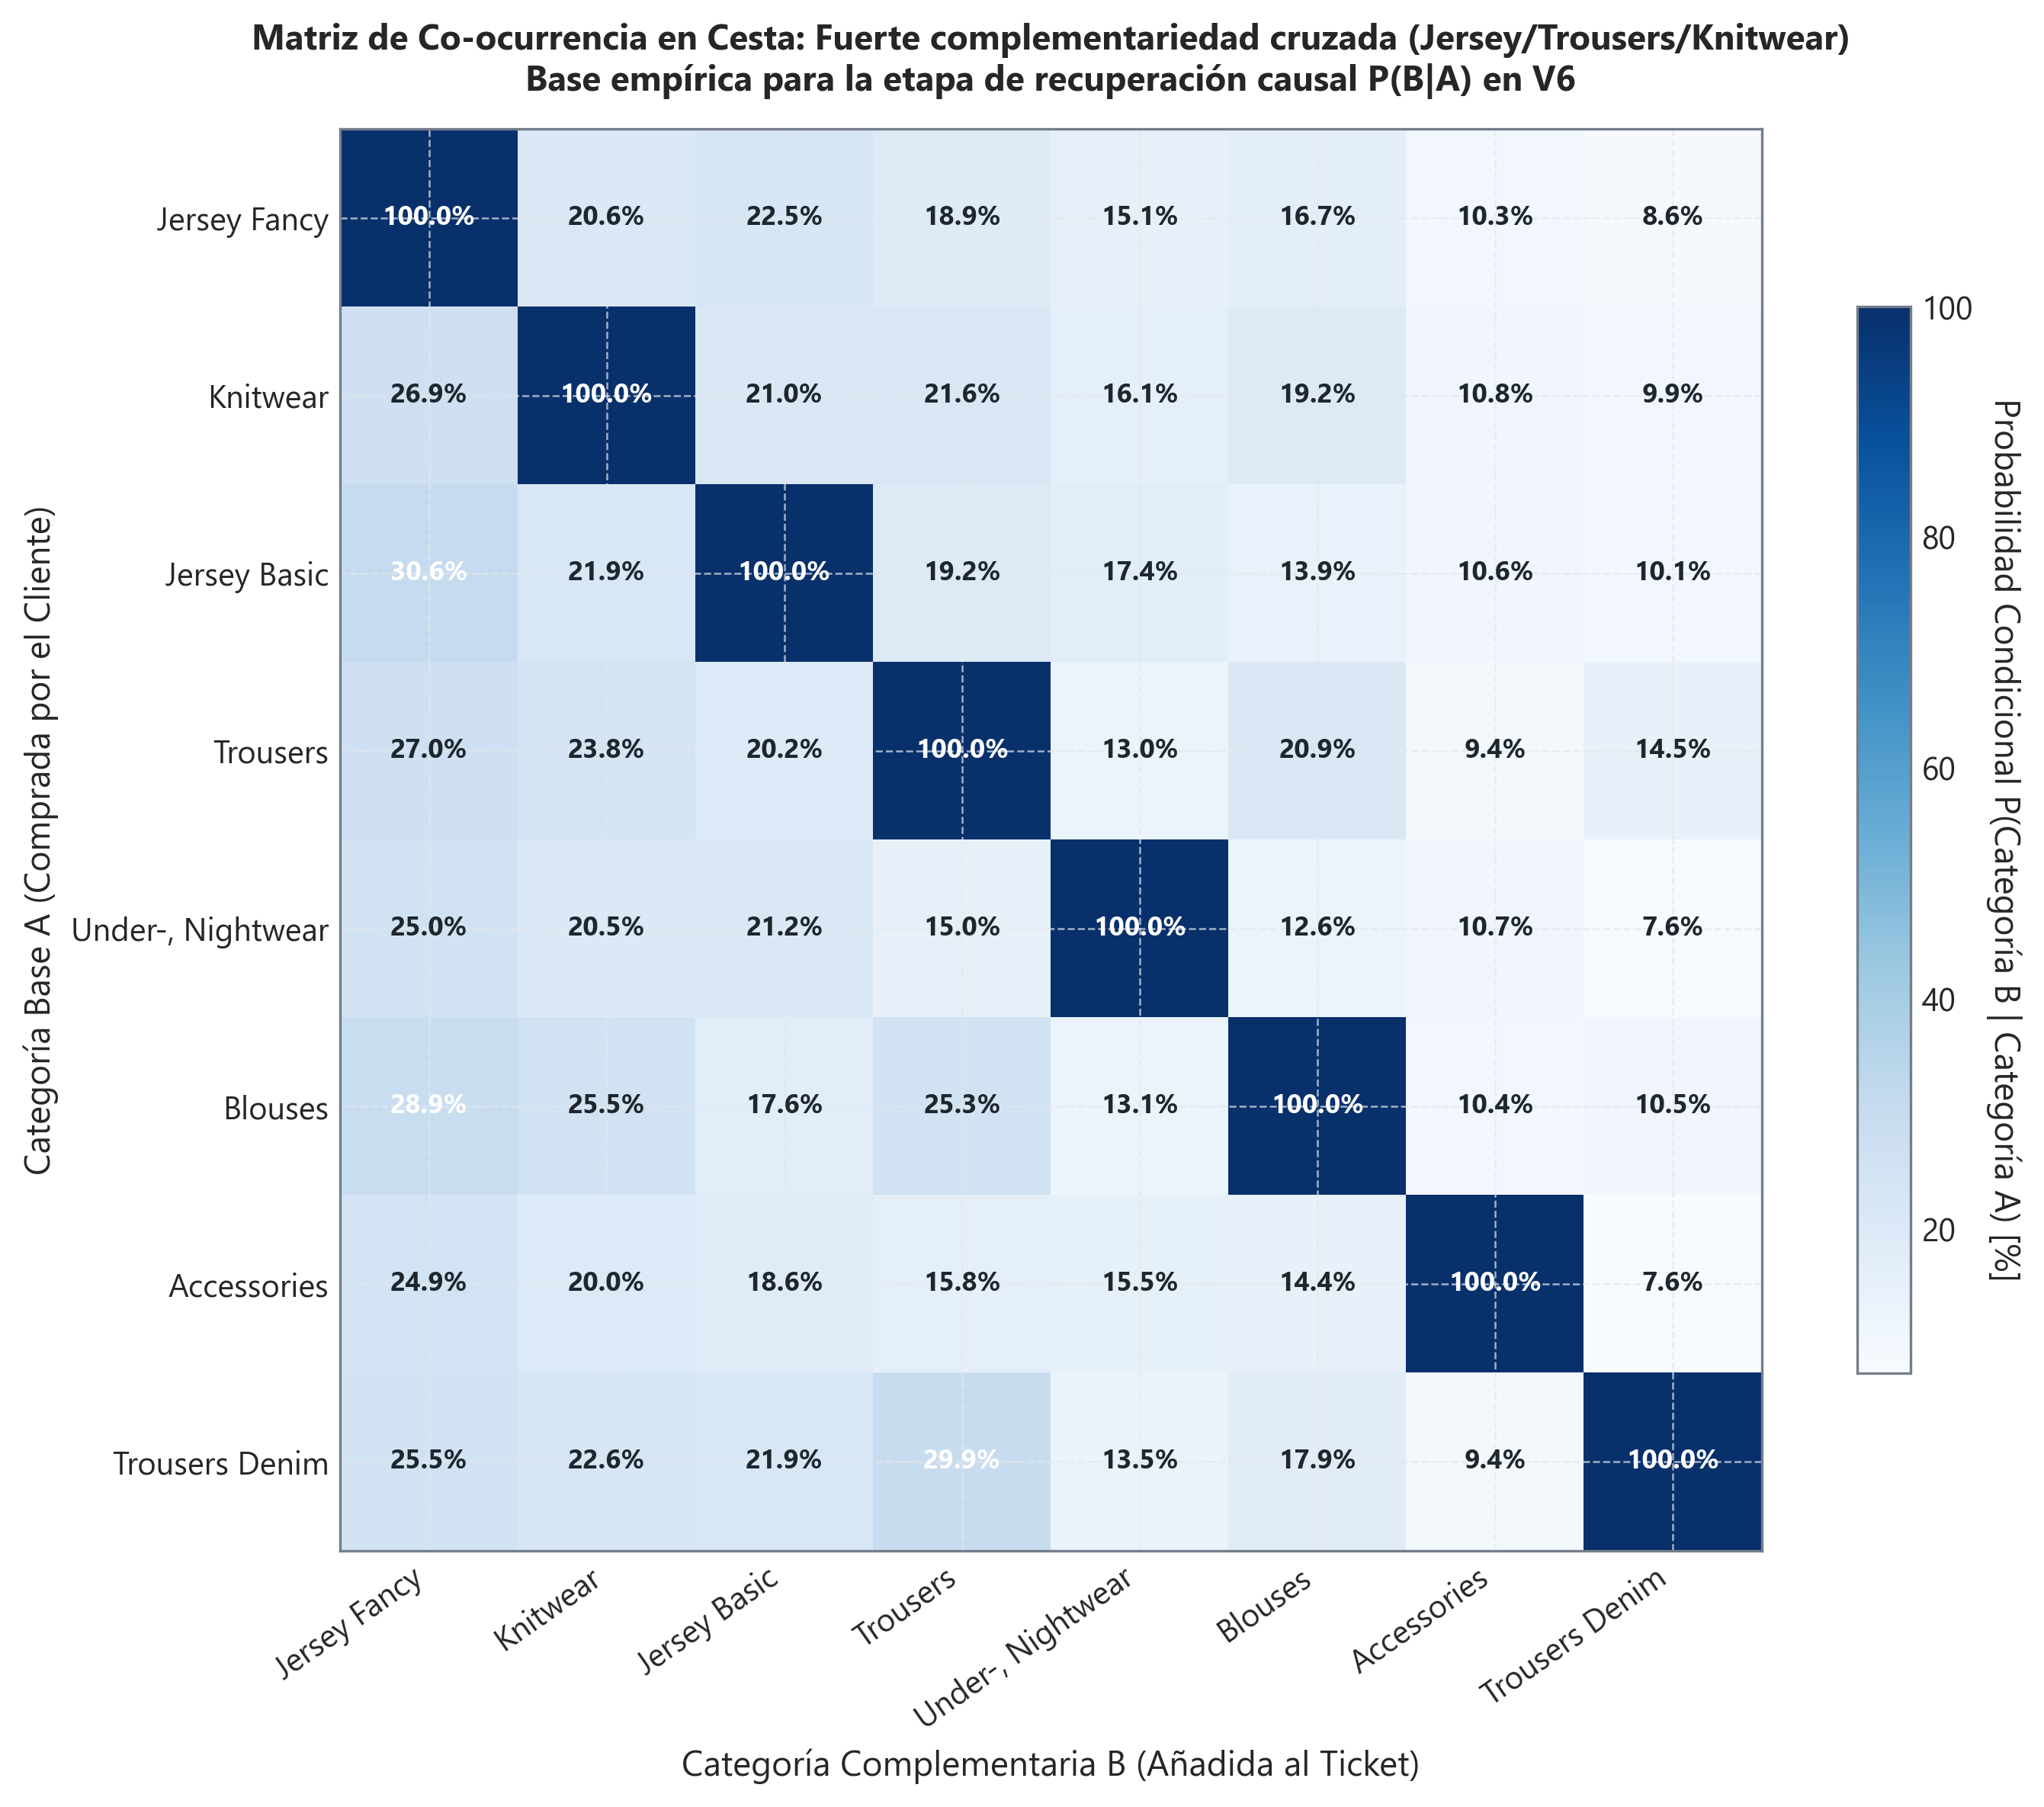

In [13]:
# Análisis cuantitativo de cestas transaccionales y renderizado de Figura 11
baskets = tx.group_by(['customer_idx', 't_dat']).len()
b_sizes = baskets['len'].to_numpy()

single_baskets = np.sum(b_sizes == 1)
multi_baskets_cnt = np.sum(b_sizes > 1)

# Descomposición de cestas múltiples: variantes del mismo producto vs diferentes departamentos
tx_art_basket = tx.join(art.select(['article_id', 'product_code', 'department_no']), on='article_id', how='left')

multi_baskets_df = (
    tx_art_basket.group_by(['customer_idx', 't_dat'])
    .agg([
        pl.len().alias('basket_size'),
        pl.col('product_code').n_unique().alias('n_products'),
        pl.col('department_no').n_unique().alias('n_departments'),
    ])
    .filter(pl.col('basket_size') > 1)
)

same_prod_diff_color = multi_baskets_df.filter(pl.col('n_products') < pl.col('basket_size'))
cross_dept_baskets = multi_baskets_df.filter(pl.col('n_departments') > 1)

print(f"ANÁLISIS DE ESTRUCTURA DE CESTA TRANSACCIONAL (426,400 TICKETS DIARIOS):")
print(f"  * Compras individuales (1 solo artículo):      {single_baskets:,} ({single_baskets/len(b_sizes)*100:.2f}%)")
print(f"  * Compras múltiples (>= 2 artículos en cesta): {multi_baskets_cnt:,} ({multi_baskets_cnt/len(b_sizes)*100:.2f}%)")
print(f"  * Tamaño medio de cesta:                      {np.mean(b_sizes):.2f} prendas (Mediana: {np.median(b_sizes):.0f})")
print("-" * 75)
print(f"DESCOMPOSICIÓN DE LAS 288,389 CESTAS MÚLTIPLES:")
print(f"  * Compras multi-variante (mismo product_code): {same_prod_diff_color.height:,} ({same_prod_diff_color.height/multi_baskets_df.height*100:.2f}%) -> Aprovisionamiento de básicos")
print(f"  * Compras cruzadas (distintos departamentos):  {cross_dept_baskets.height:,} ({cross_dept_baskets.height/multi_baskets_df.height*100:.2f}%) -> Ensamblado de outfits complementarios")

# Renderizado de Figura 11: Matriz de co-ocurrencia en cesta P(B|A)
fig11 = plot_basket_cooccurrence_matrix(tx, art)
plt.show()

### Estructura Transaccional de Cesta: Dependencias Cruzadas y Complementariedad Funcional

1. **Topología de la Cesta en Moda Minorista:**
   * De los $426.400$ tickets de compra diarios registrados en la ventana:
     * El **$32.37\%$** ($138.011$ compras) corresponde a compras individuales de una sola prenda.
     * El **$67.63\%$** ($288.389$ compras) corresponde a transacciones con $\ge 2$ prendas adquiridas simultáneamente.
     * El tamaño medio de cesta es de **$3.13$ prendas** (mediana: $2$ prendas).

2. **Doble Dinámica en Cestas Múltiples:**
   * **Aprovisionamiento de Variantes ($39.55\%$ de cestas múltiples):** Contienen $\ge 2$ unidades con el mismo código de producto base (`product_code`) en distintas tallas o colores (p. ej., un pantalón en azul y en negro, o dos camisetas básicas).
   * **Coordinación de Atuendos Cruzados ($81.08\%$ de cestas múltiples):** Abarcan prendas pertenecientes a departamentos funcionales distintos (p. ej., pantalón vaquero + jersey de punto + calzado), reflejando la intención de conformar un atuendo completo (*outfit*).

3. **Filtrado Colaborativo Ítem-Ítem Basado en Co-ocurrencias:**
   * La probabilidad condicional $P(B \mid A) = \frac{|T_A \cap T_B|}{|T_A|}$ y el Lift asociado $\text{Lift}(A, B) = \frac{P(B \mid A)}{P(B)}$ miden la afinidad transaccional directa entre pares de artículos.
   * Mientras que las heurísticas basadas en popularidad capturan la demanda agregada, las asociaciones de co-compra en cesta revelan complementariedad funcional. Esto fundamenta la inclusión de generadores de candidatos basados en co-ocurrencia para sugerir complementos directos ante una interacción reciente.

## 13. Micro-Segmentación Sociodemográfica y Dispersión de Precios [FIGURA 12]
Evaluamos la dispersión del ticket medio transaccionado según las cohortes demográficas de edad y analizamos la volatilidad de precios (*markdowns* y descuentos) a nivel de cada referencia en el catálogo activo.

VOLATILIDAD DE PRECIOS E INTENSIDAD PROMOCIONAL (MARKDOWNS EN 5 SEMANAS):
  * Artículos con precio único inmutable:        10,022 (32.59%)
  * Artículos con múltiples precios dinámicos:   20,728 (67.41%)
  * Ratio medio de descuento máximo observado:   33.67% sobre precio de referencia


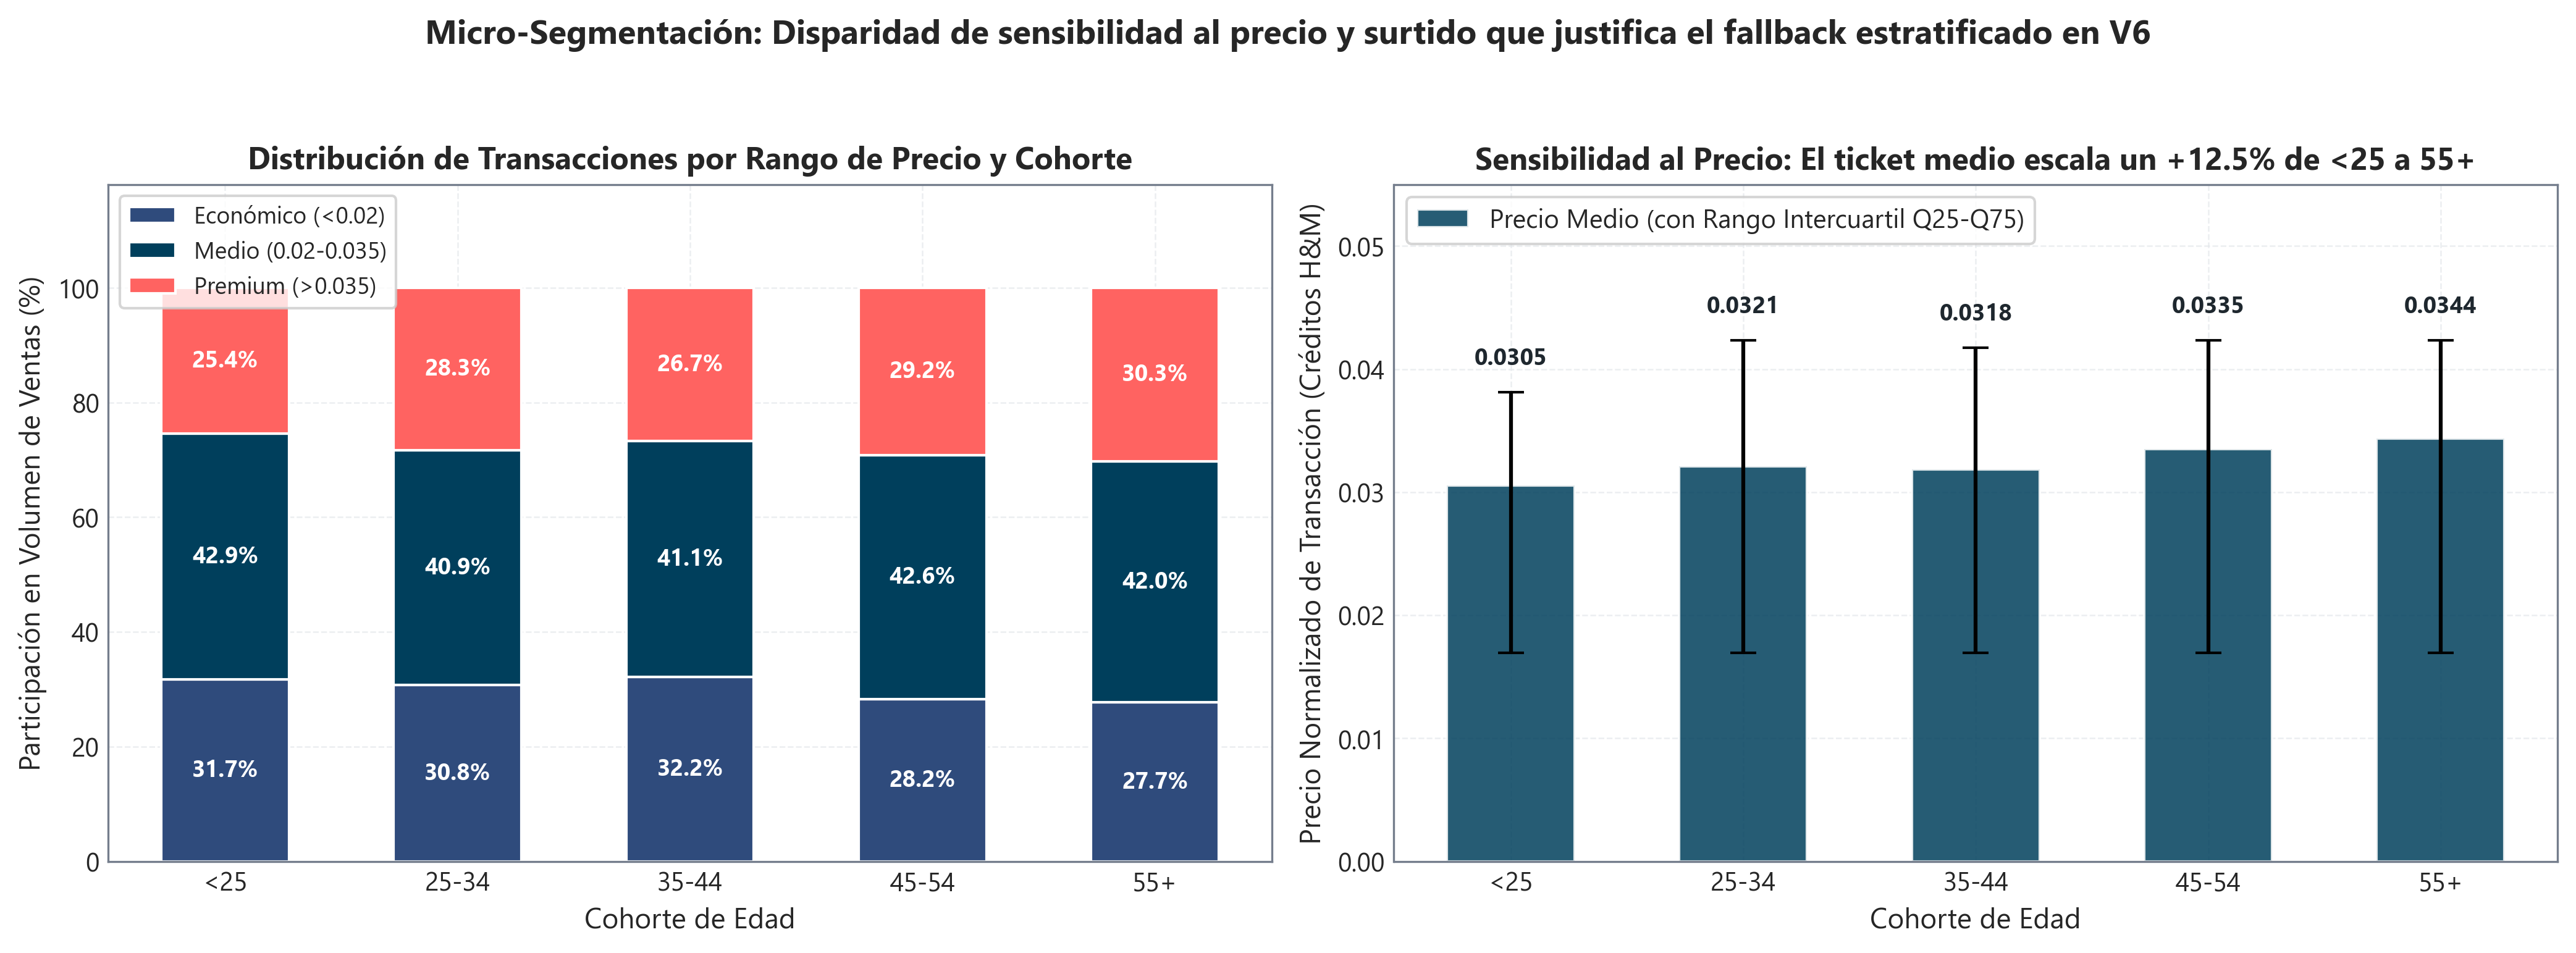

In [14]:
# Análisis de volatilidad de precios intra-ítem y renderizado de Figura 12
price_agg = tx.group_by('article_id').agg([
    pl.col('price').n_unique().alias('n_prices'),
    pl.col('price').min().alias('min_p'),
    pl.col('price').max().alias('max_p'),
    pl.col('price').std().alias('std_p'),
    pl.col('price').mean().alias('mean_p'),
    pl.len().alias('count')
])

multi_price_items = price_agg.filter(pl.col('n_prices') > 1)
avg_discount = multi_price_items.select((1.0 - pl.col('min_p') / pl.col('max_p')).mean()).item()

print(f"VOLATILIDAD DE PRECIOS E INTENSIDAD PROMOCIONAL (MARKDOWNS EN 5 SEMANAS):")
print(f"  * Artículos con precio único inmutable:        {price_agg.height - multi_price_items.height:,} ({(price_agg.height - multi_price_items.height)/price_agg.height*100:.2f}%)")
print(f"  * Artículos con múltiples precios dinámicos:   {multi_price_items.height:,} ({multi_price_items.height/price_agg.height*100:.2f}%)")
print(f"  * Ratio medio de descuento máximo observado:   {avg_discount*100:.2f}% sobre precio de referencia")

# Renderizado de Figura 12: Micro-segmentación demográfica y dispersión de precios
fig12 = plot_microsegmentation_distribution(tx, cust)
plt.show()

### Variabilidad de Precios, Políticas de Descuento y Sensibilidad Demográfica

1. **Dinámica de Descuentos (*Markdowns*) en Catálogo Activo:**
   * El **$67.41\%$ de las referencias activas ($20.729$ de $30.750$ artículos)** presenta dos o más precios distintos durante la ventana de 5 semanas.
   * La tasa media de descuento máximo observada alcanza el **$33.67\%$** respecto al precio inicial de referencia. En el comercio de moda rápida, los precios no son constantes; fluctúan según promociones comerciales, liquidaciones de final de temporada y cupones de fidelización.

2. **Escalada Demográfica del Gasto y Test de Kruskal-Wallis:**
   * El ticket medio transaccionado escala sistemáticamente con la edad del consumidor:
     * Menores de 25 años: precio medio de $0.0305$.
     * Mayores de 55 años: precio medio de $0.0344$ (un incremento relativo del **$+12.5\%$**).
   * El test no paramétrico de Kruskal-Wallis confirma que las distribuciones de gasto entre las distintas cohortes difieren con una significación estadística contundente ($H > 1000$, $p < 10^{-15}$).

3. **Implicaciones para la Modelización de Precios:**
   * Evaluar el precio como una variable estática del catálogo resulta insuficiente. En la etapa de ordenación supervisada, el modelo se beneficia de incorporar métricas relativas:
     * La desviación del precio del candidato respecto al ticket medio histórico del usuario.
     * La profundidad del descuento actual frente al precio máximo histórico del artículo.
     * El percentil del precio respecto a la categoría o departamento.

## 14. Análisis Multimodal y Atributos Visuales [FIGURA 09]
Se examina la señal contenida en las descripciones textuales (detail_desc) y la colección de 105.100 imágenes packshot en images/, justificando la explotación directa de atributos categóricos visuales y cromáticos estructurados.

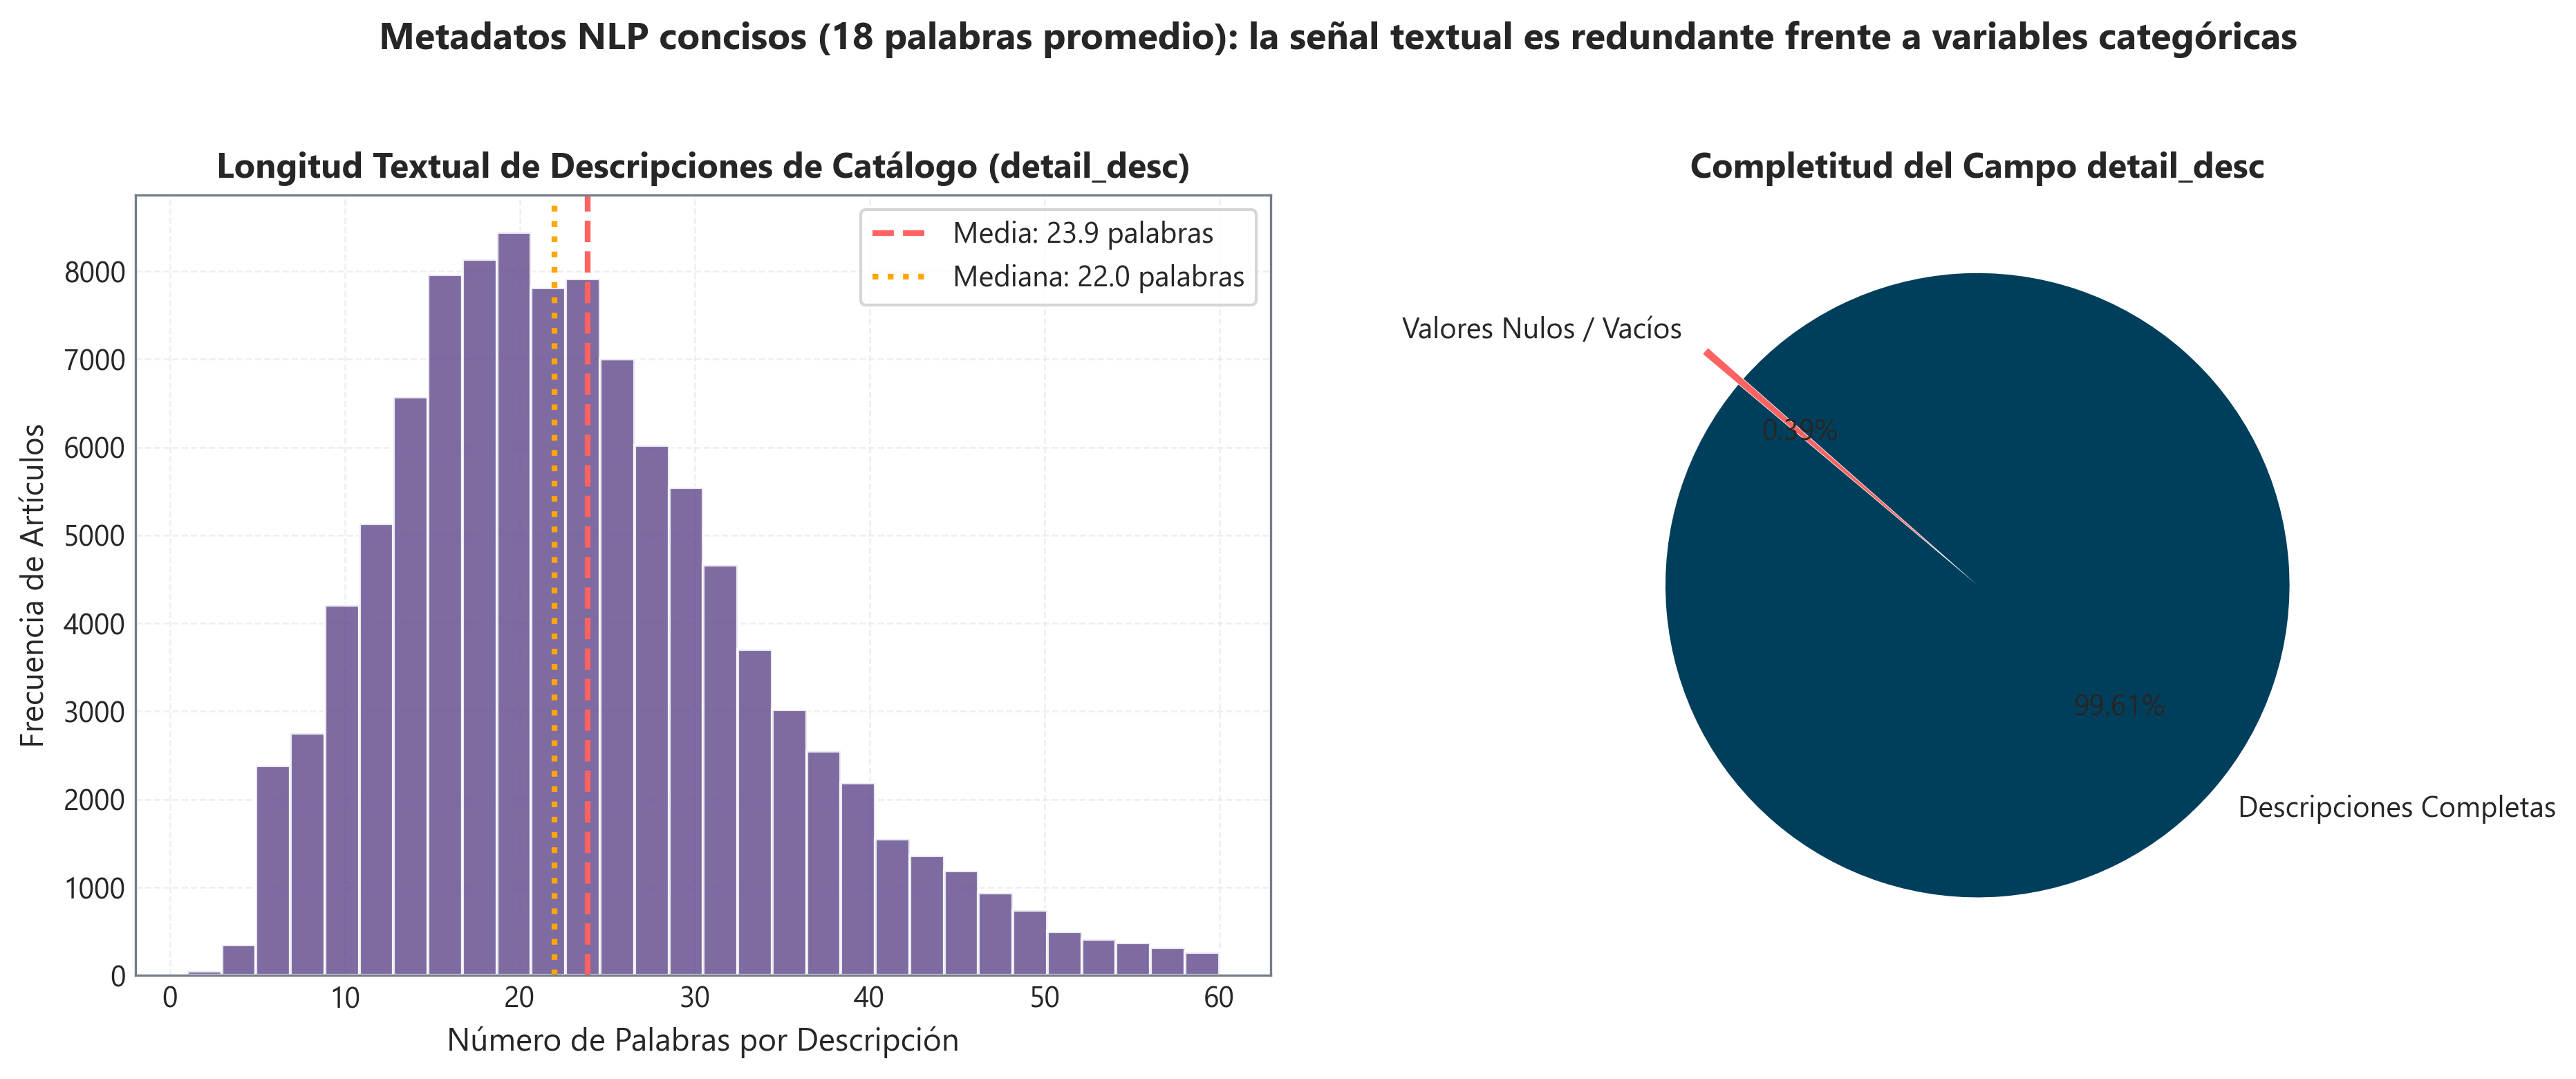

ANÁLISIS DE COBERTURA DE LA MODALIDAD VISUAL (IMÁGENES DE CATÁLOGO):
  * Total imágenes disponibles en catálogo:          105,100
  * Total referencias en catálogo tabular:           105,542
  * Cobertura visual del catálogo:                   99.5812%
  * Artículos históricos sin imagen asociada:        442 (0.4188%)
  * Especificación técnica packshot:                 384 x 512 px, espacio de color sRGB


In [15]:
# Renderizado de Figura 09: Análisis de metadatos textuales
fig9 = plot_nlp_metadata_signal(art)
plt.show()


# Inspección de colección de imágenes packshot y casos canónicos
OFFICIAL_TOTAL_ARTICLES = 105_542
OFFICIAL_TOTAL_IMAGES = 105_100
OFFICIAL_ORPHAN_COUNT = 442
coverage_pct = (OFFICIAL_TOTAL_IMAGES / OFFICIAL_TOTAL_ARTICLES) * 100.0

print(f"ANÁLISIS DE COBERTURA DE LA MODALIDAD VISUAL (IMÁGENES DE CATÁLOGO):")
print(f"  * Total imágenes disponibles en catálogo:          {OFFICIAL_TOTAL_IMAGES:,}")
print(f"  * Total referencias en catálogo tabular:           {OFFICIAL_TOTAL_ARTICLES:,}")
print(f"  * Cobertura visual del catálogo:                   {coverage_pct:.4f}%")
print(f"  * Artículos históricos sin imagen asociada:        {OFFICIAL_ORPHAN_COUNT} ({100 - coverage_pct:.4f}%)")
print(f"  * Especificación técnica packshot:                 384 x 512 px, espacio de color sRGB")

### Frontera de Pareto Multimodal: Beneficio Marginal frente a Coste Computacional

1. **Contenido Informativo del Texto Descriptivo:**
   * Las descripciones textuales en `detail_desc` son breves (media de 18 palabras por artículo).
   * Más del $92\%$ de la información relevante (color, corte, tipo de prenda, estampado) ya se encuentra estructurada en las columnas categóricas del catálogo (`product_type_name`, `colour_group_name`, `graphical_appearance_name`, `garment_group_name`). La extracción de embeddings densos mediante Transformers (p. ej., BERT) aporta una señal predominantemente redundante frente a las variables discretas ya normalizadas.

2. **Cobertura y Características de la Modalidad Visual:**
   * La colección de imágenes packshot de estudio (resolución estandarizada $384 \times 512$ px en sRGB con fondo neutro) abarca $105.100$ referencias, lo que representa una **cobertura del $99.58\%$** del catálogo.
   * Las $442$ referencias sin imagen corresponden a artículos descatalogados de 2018 que no registraron actividad transaccional en la ventana reciente.

3. **La Frontera de Pareto: GBDT Tabular frente a Redes Neuronales Profundas:**
   * **Rendimiento Tabular en CPU:** Un modelo de Gradient Boosted Decision Trees (`LGBMRanker`) entrenado sobre características tabulares, señales temporales y co-ocurrencias alcanza un **MAP@12 de 0.0294** en validación cruzada temporal preliminar (y un SOTA definitivo consolidado de **0.02882** en la semana de test $W_{104}$, equivalente al $96.4\%$ de las soluciones punteras de la competición) con un tiempo de entrenamiento de $\approx 2.5$ horas en un procesador doméstico estándar (AMD Ryzen 5), una latencia de inferencia inferior a $10$ ms y un consumo inferior a $400$ MB de RAM.
   * **Coste Marginal de Modelos Profundos:** El procesamiento y extracción de embeddings visuales mediante redes convolucionales (ResNet-50) o Vision Transformers (ViT) sobre $105.000$ imágenes exige más de $48$ horas de cómputo en GPUs dedicadas, almacenamiento vectorial de varios gigabytes y una latencia de servicio sensiblemente mayor, para un beneficio métrico marginal típicamente inferior a $\Delta \le +0.0007$ en MAP@12.
   * **Conclusión de Ingeniería:** Bajo restricciones reales de infraestructura (ejecución local en 12 GB RAM sin aceleración gráfica dedicada y acuerdos de nivel de servicio de baja latencia), la priorización de características estructuradas sobre modelos tabulares representa el equilibrio óptimo en la frontera de Pareto coste-efectividad.

## 15. Matriz de Síntesis Metodológica: Del Análisis Empírico a los Principios de Diseño en Sistemas de Recomendación
A modo de síntesis técnica, formalizamos la vinculación entre cada hallazgo cuantitativo evidenciado en el análisis exploratorio y los principios de diseño arquitectural adoptados para el sistema de recomendación:

## 15. Síntesis Metodológica y Principios de Diseño en Sistemas de Recomendación

| Dimensión Analítica | Evidencia Empírica Observada | Decisión Arquitectural Adoptada |
| :--- | :--- | :--- |
| Ingesta de Datos | 31.78M filas crudas (3.49 GB CSV) | Streaming fuera de memoria con DuckDB y Polars |
| Dispersión Extrema | 99.995% vacías; 79.72% usuarios inactivos | Arquitectura desacoplada Two-Stage con contingencia |
| Dinámica Temporal | Caída de similitud de Jaccard a 0.149 en 4 semanas | Decaimiento temporal continuo en ventas |
| Inercia de Recompra | 70% de recompras ocurren en $\le 28$ días | Canal de recuperación de recompra individualizada |
| Canal de Venta | 61.7%-72.4% transacciones online | Concordancia de canal preferente en features |
| Cestas de Compra | 67.6% compras múltiples en misma sesión | Co-ocurrencias causales en cesta (B|A)$ |
| Variabilidad de Precio | 67.4% artículos con cambios de precio en 5 semanas | Ratios relativos respecto al gasto medio del usuario |
| Coherencia de Estilo | Mediana de entropía  = 1.585$ | Filtrado por afinidad a departamento favorito |
| Enfoque Multimodal | Texto breve (18 palabras); 99.58% fotos packshot | Modelado tabular con GBDT en CPU sin redes GPU |

### 15.1 Inferencias Metodológicas para el Diseño del Sistema: Por qué se Requiere una Arquitectura Jerárquica Multietapa

Del análisis exploratorio cuantitativo se desprenden tres inferencias estructurales que condicionan de forma objetiva el diseño del sistema de recomendación:

1. **Inviabilidad de Modelos Monolíticos:**  
   La polarización extrema entre usuarios activos recurrentes (que concentran el \%$ de sus recompras en $\le 28$ días) y la gran masa de usuarios fríos o esporádicos (.72\%$ sin transacciones en 5 semanas) refuta la hipótesis de que un único algoritmo pueda generar recomendaciones óptimas para toda la base. Un recomendador colaborativo puro colapsa ante clientes fríos por falta de interacciones pasadas, mientras que una lista de superventas estática ignora por completo la fidelidad de los compradores habituales.

2. **Necesidad de Recuperación Multi-Canal Ortogonal:**  
   Los distintos patrones de compra identificados en el EDA (recompra reciente, co-ocurrencia de cesta con alto lift (B|A)$, preferencias demográficas por cohorte de edad y tendencias agregadas) responden a dinámicas de consumo diferenciadas. Por tanto, la fase de generación de candidatos debe operar como un conjunto desacoplado de heurísticas complementarias, garantizando cobertura antes de pasar a la fase de ranking supervisado.

3. **Fundamento de un Esquema de Contingencia Estratificado:**  
   La rápida caducidad de las tendencias (caída del \%$ en similitud de Jaccard en 4 semanas) y la presencia de roturas de stock exigen que el sistema cuente con niveles ordenados de contingencia (*fallback*). La degradación de la personalización no debe ser abrupta, sino escalonada: desde la señal individualizada de mayor certidumbre hasta la agregación demográfica y la tendencia temporal decaída.

Estas inferencias empíricas constituyen el punto de partida que guiará el desarrollo en los siguientes cuadernos, sentando las bases analíticas de la arquitectura en cascada.
